# 04 — DistilBERT Prosodic Boundary Classifier (Multi-corpus)

Fine-tunes `distilbert-base-uncased` on prosodic boundary labels from one or more corpora.

**Task:** Multi-task token classification — boundary (`b`), intonation type (`i`), break index (`x`).

**Baseline to beat:** PSST text-only GPT-Neo F1 = 0.77

**Fixed test set:** SBC001–005 for boundary detection and intonation at boundaries (gold conversational, held out from all training). The entire Boston University Radio News Corpus for break index verifcation and testing.

Disclaimer: Code was largely generated with the help of Claude Sonnet 4.6 (Anthropic, 2026). Prompts, code tweaks and verification by me.

---

## How to use this notebook

Run cells **top to bottom**. Cells you will edit regularly:

| Cell | Purpose |
|---|---|
| **Cell 1** | Paths, hyperparameter defaults, corpus load flags |
| **Cell 4** | Corpus loading (runs automatically based on flags) |
| **Cell 14** | Run queue — define which datasets + overrides per run |

Everything else runs unchanged between experiments.

---

## Corpus registry

Corpora are loaded in Cell 4 into a `CORPUS_REGISTRY` dict, then referenced by name in the run queue:

| Key | Corpus | Notes |
|---|---|---|
| `"libri"` | LibriTTS clean-100 + clean-360 | Silver-standard, read speech, ~145k samples |
| `"sbc"` | SBCSAE SBC006–SBC060 | Gold-standard, conversational (SBC001–005 are test-only) |
| `"bu"` | BU Radio News Corpus | Gold-standard, broadcast news, ~426 samples |

Add future corpora by adding a flag + load snippet in Cell 4 and a new key to `CORPUS_REGISTRY`.

---

## Output folder structure

```
models/
└── {run_notes}/                       # name of run
    ├── checkpoint/                    ← model weights + tokenizer
    ├── {run_id}_hparams.json
    ├── {run_id}_test_predictions.json
    ├── {run_id}_curves.png
    └── {run_id}_confusion_matrix.png
```


---
## Section 1 · Configuration

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — CONFIGURATION                                      ║
# ║  Edit paths, hyperparameter defaults, and corpus flags here. ║
# ╚══════════════════════════════════════════════════════════════╝
import os, json, hashlib, re
from datetime import datetime

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT = "/content/drive/MyDrive/Capstone/project"
RUNS_ROOT  = f"{DRIVE_ROOT}/models"
LABELS_ROOT  = f"{DRIVE_ROOT}/labels"

# Corpus label roots — add new corpora here
BATCHED_ROOT_LIBRI_100 = f"{LABELS_ROOT}/clean-100"
BATCHED_ROOT_LIBRI_360 = f"{LABELS_ROOT}/clean-360"
BATCHED_ROOT_SBC       = f"{LABELS_ROOT}/sbcsae"
BATCHED_ROOT_BU        = f"{LABELS_ROOT}/bu"
BATCHED_ROOT_PS        = f"{LABELS_ROOT}/ps"
# BATCHED_ROOT_NEWCORPUS = f"{DRIVE_ROOT}/labels/newcorpus"

# ── Corpus load flags ─────────────────────────────────────────────────────────
# Set False to skip loading a corpus (saves time if you won't use it this session).
# A run that requests a skipped corpus will raise a KeyError.
LOAD_LIBRI = True   # ~145k samples — slow to load
LOAD_SBC   = True   # ~4k samples
LOAD_BU    = True   # ~426 samples
LOAD_PS    = True   # People's Speech silver-standard
# LOAD_NEWCORPUS = True

# SBC test holdout IDs — these are NEVER added to the registry or any training set
SBC_TEST_IDS = set(f"SBC{str(n).zfill(3)}" for n in range(1, 6))  # SBC001–SBC005

# ── Data split (train/val only — test is always SBC001–005) ───────────────────
SPLIT_SEED = 42
TRAIN_FRAC = 0.80
VAL_FRAC   = 0.10

# ── Text pre-processing ───────────────────────────────────────────────────────
STRIP_PUNCTUATION = False
EXTRA_FEATURES    = []

# ── POS feature flags (defaults — can be overridden per-run in Cell 14) ───────
# TRAIN_ON_TEXT : DistilBERT receives the real word sequence as input.
# TRAIN_ON_POS  : POS embeddings are injected post-transformer (combined mode).
#                 Requires TRAIN_ON_TEXT=True. POS-only mode (TRAIN_ON_TEXT=False,
#                 TRAIN_ON_POS=True) replaces input words with POS abbreviations.
# Neither True  : invalid — raises an error in run_experiment().
# Default here is text-only; override per run in the RUNS queue (Cell 14).
TRAIN_ON_TEXT     = True
TRAIN_ON_POS      = False
POS_EMBEDDING_DIM = 64      # embedding size before Linear projection to H=768
                             # only used in combined mode (text+POS)

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5
NUM_EPOCHS    = 3
WARMUP_STEPS  = 0
WEIGHT_DECAY  = 0.01

# ── Class-imbalance strategy (boundary head only) ─────────────────────────────
IMBALANCE_STRATEGY   = "none"
BOUNDARY_LOSS_WEIGHT = 5.0

# ── Multi-task loss weights ───────────────────────────────────────────────────
BOUNDARY_TASK_WEIGHT   = 1.0
INTONATION_TASK_WEIGHT = 1.0
BREAK_IDX_TASK_WEIGHT  = 1.0

# ── Run metadata ──────────────────────────────────────────────────────────────
RUN_NOTES = ""

# ── Dual checkpoint (optional) ────────────────────────────────────────────────
# When True, also saves the checkpoint with best val intonation F1 and runs a
# second test evaluation pass. Off by default — enable per-run via overrides.
SAVE_INTONATION_CHECKPOINT = True

# ── Model registry ─────────────────────────────────────────────────────────
# Tracks every run's deterministic name → parameters. Lives at RUNS_ROOT
# (parent of full/ and partial/), keyed by auto-incrementing model number.
MODEL_REGISTRY_PATH = f"{RUNS_ROOT}/model_registry.json"

print("✓ Configuration loaded.")
print(f"  Corpus flags:  LIBRI={LOAD_LIBRI}  SBC={LOAD_SBC}  BU={LOAD_BU}  PS={LOAD_PS}")
print(f"  POS flags:     TRAIN_ON_TEXT={TRAIN_ON_TEXT}  TRAIN_ON_POS={TRAIN_ON_POS}  POS_EMB_DIM={POS_EMBEDDING_DIM}")
print(f"  SBC test IDs:  {sorted(SBC_TEST_IDS)}")
print(f"  Dual checkpoint: {SAVE_INTONATION_CHECKPOINT}")

from google.colab import drive
import os

drive.mount("/content/drive", force_remount=True)
os.makedirs(RUNS_ROOT, exist_ok=True)

✓ Configuration loaded.
  Corpus flags:  LIBRI=True  SBC=True  BU=True  PS=True
  POS flags:     TRAIN_ON_TEXT=True  TRAIN_ON_POS=False  POS_EMB_DIM=64
  SBC test IDs:  ['SBC001', 'SBC002', 'SBC003', 'SBC004', 'SBC005']
  Dual checkpoint: True
Mounted at /content/drive


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Deterministic run naming                                    ║
# ║  Computes a canonical name from dataset list + key params.   ║
# ║  Same inputs always produce the same name — no manual typing.║
# ╚══════════════════════════════════════════════════════════════╗

_DATASET_LETTERS = {"libri": "L", "ps": "P", "sbc": "S"}
_FULL_SET = {"libri", "ps", "sbc"}

_DEFAULT_LR      = 2e-5
_DEFAULT_WARMUP  = 0

def _format_lr(lr):
    """2e-05 → 'lr2e5'   1e-05 → 'lr1e5'   3e-05 → 'lr3e5'"""
    s = f"{lr:.0e}"            # e.g. "2e-05"
    mantissa, exp = s.split("e")
    exp_num = exp.lstrip("+-").lstrip("0") or "0"
    return f"lr{mantissa}e{exp_num}"

def compute_run_name(datasets: list[str], run_cfg: dict) -> tuple[str, str]:
    # ── Dataset letters, canonical order ───────────────────────────────────
    letters = "".join(
        _DATASET_LETTERS[d] for d in ["libri", "ps", "sbc"] if d in datasets
    )
    # ── Loss suffix (always present) ────────────────────────────────────────
    if run_cfg["IMBALANCE_STRATEGY"].startswith("weight"):
        _blw = run_cfg["BOUNDARY_LOSS_WEIGHT"]
        _blw_str = str(int(_blw)) if _blw == int(_blw) else str(_blw).replace(".", "p")
        loss_suffix = f"wl{_blw_str}"
    else:
        loss_suffix = "stl"
    parts = [letters, loss_suffix]

    # ── POS suffix (optional) ───────────────────────────────────────────────
    train_text = run_cfg["TRAIN_ON_TEXT"]
    train_pos  = run_cfg["TRAIN_ON_POS"]
    if train_pos and not train_text:
        parts.append("posonly")
    elif train_pos and train_text:
        parts.append("pos")
    # else: text-only, default, no suffix

    # ── Punctuation suffix (optional) ───────────────────────────────────────
    if not run_cfg["STRIP_PUNCTUATION"]:
        parts.append("pp")
    # else: stripped, default, no suffix

    # ── Learning rate suffix (optional) ─────────────────────────────────────
    if run_cfg["LEARNING_RATE"] != _DEFAULT_LR:
        parts.append(_format_lr(run_cfg["LEARNING_RATE"]))

    # ── Warmup suffix (optional) ────────────────────────────────────────────
    if run_cfg["WARMUP_STEPS"] != _DEFAULT_WARMUP:
        parts.append(f"warmup{run_cfg['WARMUP_STEPS']}")

    name = "_".join(parts)
    category = "full" if set(datasets) == _FULL_SET else "partial"
    return name, category

print("✓ compute_run_name() defined.")

def resolve_run_path(name: str, category: str) -> tuple[str, str]:
    """
    Resolve the final run directory for a given deterministic name,
    appending a numeric disambiguator (_2, _3, ...) if the name is
    already taken on disk. Never overwrites an existing run directory.
    """
    base_dir = os.path.join(RUNS_ROOT, category)
    os.makedirs(base_dir, exist_ok=True)

    candidate = name
    suffix = 1
    while os.path.isdir(os.path.join(base_dir, candidate)):
        suffix += 1
        candidate = f"{name}_{suffix}"

    run_dir = os.path.join(base_dir, candidate)
    return candidate, run_dir

def _load_registry() -> dict:
    """Load model_registry.json, or return an empty dict if it doesn't exist yet."""
    if os.path.exists(MODEL_REGISTRY_PATH):
        with open(MODEL_REGISTRY_PATH) as f:
            return json.load(f)
    return {}


def _next_model_number(registry: dict) -> int:
    """Next available model number. Starts at 1 if registry is empty."""
    if not registry:
        return 1
    return max(int(k) for k in registry) + 1


def register_model(name: str, run_dir: str, datasets: list[str], run_cfg: dict,
                   loss_suffix_label: str) -> int:
    """
    Append a new entry to model_registry.json and return its assigned number.

    Parameters
    ----------
    name               : deterministic run name, e.g. "LPS_stl" or "LS_wl3"
    run_dir             : full path to the run directory
    datasets            : list[str] used for training
    run_cfg             : resolved config dict (after overrides applied)
    loss_suffix_label   : "standard" or "weighted" — spelled out for the registry
                          (the folder/name suffix abbreviates to "stl", or to
                          "wl{boundary_loss_weight}" e.g. "wl3"/"wl5"/"wl7" —
                          the weight value is load-bearing in the name now,
                          since different weights produce materially
                          different results, not just a cosmetic variant)
    """
    registry = _load_registry()
    model_num = _next_model_number(registry)

    rel_path = os.path.relpath(run_dir, RUNS_ROOT)

    registry[str(model_num)] = {
        "name": name,
        "path": rel_path,
        "datasets": datasets,
        "loss": loss_suffix_label,
        "boundary_loss_weight": run_cfg["BOUNDARY_LOSS_WEIGHT"] if loss_suffix_label == "weighted" else None,
        "train_on_text": run_cfg["TRAIN_ON_TEXT"],
        "train_on_pos": run_cfg["TRAIN_ON_POS"],
        "strip_punctuation": run_cfg["STRIP_PUNCTUATION"],
        "learning_rate": run_cfg["LEARNING_RATE"],
        "warmup_steps": run_cfg["WARMUP_STEPS"],
        "num_epochs": run_cfg["NUM_EPOCHS"],
        "run_notes": run_cfg["RUN_NOTES"],
    }

    with open(MODEL_REGISTRY_PATH, "w") as f:
        json.dump(registry, f, indent=2)

    return model_num

print("✓ resolve_run_path() defined.")
print("✓ Model registry functions defined.")


✓ compute_run_name() defined.
✓ resolve_run_path() defined.
✓ Model registry functions defined.


---
## Section 2 · Environment Setup

Run once per Colab session. Safe to re-run — all steps are idempotent.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Install packages                                   ║
# ╚══════════════════════════════════════════════════════════════╝

!pip install -q transformers datasets scikit-learn matplotlib

import torch
print(f"\n✓ PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("⚠  No GPU — training will be slow.")
    print("   Runtime → Change runtime type → T4 GPU")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Device: {device}")



✓ PyTorch 2.11.0+cu128 | CUDA: True
   Device: cuda


---
## Section 3 · Imports

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Imports                                            ║
# ╚══════════════════════════════════════════════════════════════╝
import os, json, string, random, shutil, traceback, gc, hashlib, subprocess
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
)
from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    DistilBertPreTrainedModel,
    DistilBertConfig,
    get_linear_schedule_with_warmup,
)
from tqdm.notebook import tqdm, tqdm as tqdm_nb

class _NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.integer):  return int(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)

torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)
random.seed(SPLIT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SPLIT_SEED)

print("✓ Imports complete.")


✓ Imports complete.


---
## Section 4 · Load Corpora

Loads each corpus based on the flags in Cell 1. Splits SBC into train (`sbc`) and fixed test holdout (`samples_sbc_test`) at load time.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Load corpora                                       ║
# ║                                                              ║
# ║  Loads each corpus based on flags set in Cell 1.             ║
# ║  Builds CORPUS_REGISTRY (training data only) and             ║
# ║  fixed evaluation sets (never in registry):                  ║
# ║    samples_sbc_test — boundary + intonation eval (SBC001–005)║
# ║    samples_bu       — break index eval (full BU corpus)      ║
# ║                                                              ║
# ║  To add a future corpus:                                     ║
# ║    1. Add LOAD_NEWCORPUS flag + BATCHED_ROOT_NEWCORPUS in C1 ║
# ║    2. Add a load block below (copy any existing block)       ║
# ║    3. Add key → samples to CORPUS_REGISTRY at the bottom     ║
# ╚══════════════════════════════════════════════════════════════╝

def load_label_files_batched(batched_root, label=""):
    """
    Load all samples from batch_*.json files in batched_root.

    Batch file layout (produced by annotation_pipeline_*.ipynb):
        batch_0000.json  ← dict keyed by sample_id, each value has "b", "i", "x"
        ...

    Returns
    -------
    samples : list[dict]  — keys: sample_id, tokens, boundary_labels,
                            intonation_labels, break_idx_labels
    meta    : dict        — empty placeholder (meta.json not bundled)
    """
    batch_files = sorted(
        f for f in os.listdir(batched_root)
        if f.startswith("batch_") and f.endswith(".json")
    )
    if not batch_files:
        raise FileNotFoundError(
            f"No batch files found in {batched_root}.\n"
            "Check path or run the relevant annotation pipeline first."
        )
    tag = f" [{label}]" if label else ""
    print(f"Found {len(batch_files)} batch files in {batched_root}{tag}.")

    samples, n_skipped = [], 0
    for fname in tqdm(batch_files, desc=f"Loading{tag}", unit="batch"):
        with open(os.path.join(batched_root, fname)) as f:
            batch = json.load(f)
            for sid, data in batch.items():
                b, i, x = data["b"], data["i"], data["x"]
                n = len(b["tokens"])
                x_labels = x["labels"] if x is not None else [""] * n
                if not (len(b["consensus"]) == len(i["labels"]) == len(x_labels) == n):
                    print(f"  ⚠ {sid}: mismatched label lengths — skipping.")
                    n_skipped += 1
                    continue
                samples.append({
                    "sample_id":         sid,
                    "tokens":            b["tokens"],
                    "boundary_labels":   b["consensus"],
                    "intonation_labels": i["labels"],
                    "break_idx_labels":  x_labels,
                })

    print(f"  ✓ {len(samples):,} samples loaded  ({n_skipped} skipped).")
    if samples:
        total_tokens     = sum(len(s["tokens"])          for s in samples)
        total_boundaries = sum(sum(s["boundary_labels"]) for s in samples)
        pos_rate         = total_boundaries / max(total_tokens, 1)
        ratio            = (1 - pos_rate) / max(pos_rate, 1e-9)
        print(f"  Total words:     {total_tokens:,}")
        print(f"  Boundary rate:   {100*pos_rate:.1f}%  (ratio ≈ {ratio:.1f}:1)")
        print(f"  → Suggested BOUNDARY_LOSS_WEIGHT: ~{round(ratio)}.0")
    return samples, {}


# ── CORPUS_REGISTRY (training data only) ─────────────────────────────────────
# Maps name → sample list. Only loaded corpora appear here.
# Valid keys: "libri", "sbc", "ps"
# BU is evaluation-only and never enters the registry — see below.
CORPUS_REGISTRY = {}

# ── LibriTTS ──────────────────────────────────────────────────────────────────
if LOAD_LIBRI:
    _samples_100, _ = load_label_files_batched(BATCHED_ROOT_LIBRI_100, "libri-100")
    _samples_360, _ = load_label_files_batched(BATCHED_ROOT_LIBRI_360, "libri-360")
    samples_libri = _samples_100 + _samples_360
    print(f"  LibriTTS total: {len(samples_libri):,} samples")
    CORPUS_REGISTRY["libri"] = samples_libri
else:
    print("  ⚠  LOAD_LIBRI=False — 'libri' not in registry.")

# ── SBCSAE ────────────────────────────────────────────────────────────────────
if LOAD_SBC:
    _all_sbc, _ = load_label_files_batched(BATCHED_ROOT_SBC, "sbcsae")
    # Split at load time: SBC001–005 → fixed eval holdout (never in registry)
    samples_sbc_test  = [s for s in _all_sbc
                         if s["sample_id"][:6] in SBC_TEST_IDS]
    samples_sbc_train = [s for s in _all_sbc
                         if s["sample_id"][:6] not in SBC_TEST_IDS]
    print(f"  SBC train: {len(samples_sbc_train):,}  |  SBC eval holdout: {len(samples_sbc_test):,}")
    CORPUS_REGISTRY["sbc"] = samples_sbc_train
else:
    print("  ⚠  LOAD_SBC=False — 'sbc' not in registry.")
    samples_sbc_test = []
    print("  ⚠  samples_sbc_test is empty — test set will be a random split.")

# ── BU Radio News — evaluation only, never in registry ────────────────────────
# Full BU corpus is used as the gold-standard break index evaluation set.
# BU is never added to CORPUS_REGISTRY or any training pool.
# Models trained without BU data can be published freely.
if LOAD_BU:
    samples_bu, _ = load_label_files_batched(BATCHED_ROOT_BU, "bu")
    print(f"  BU eval holdout: {len(samples_bu):,} samples (break index eval only — never in training)")
else:
    samples_bu = []
    print("  ⚠  LOAD_BU=False — BU break index evaluation will be skipped.")

# ── People's Speech ───────────────────────────────────────────────────────────
if LOAD_PS:
    samples_ps, _ = load_label_files_batched(BATCHED_ROOT_PS, "ps")
    CORPUS_REGISTRY["ps"] = samples_ps
else:
    print("  ⚠  LOAD_PS=False — 'ps' not in registry.")

# ── ADD FUTURE CORPORA HERE ───────────────────────────────────────────────────
# if LOAD_NEWCORPUS:
#     samples_newcorpus, _ = load_label_files_batched(BATCHED_ROOT_NEWCORPUS, "newcorpus")
#     CORPUS_REGISTRY["newcorpus"] = samples_newcorpus
# else:
#     print("  ⚠  LOAD_NEWCORPUS=False — 'newcorpus' not in registry.")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n✓ CORPUS_REGISTRY keys:", list(CORPUS_REGISTRY.keys()))
print(f"  SBC eval holdout (SBC001–005):  {len(samples_sbc_test):,} samples  [boundary + intonation]")
print(f"  BU eval holdout  (full corpus): {len(samples_bu):,} samples  [break index]")

Found 34 batch files in /content/drive/MyDrive/Capstone/project/labels/clean-100 [libri-100].


Loading [libri-100]:   0%|          | 0/34 [00:00<?, ?batch/s]

  ✓ 33,142 samples loaded  (0 skipped).
  Total words:     572,388
  Boundary rate:   18.0%  (ratio ≈ 4.6:1)
  → Suggested BOUNDARY_LOSS_WEIGHT: ~5.0
Found 115 batch files in /content/drive/MyDrive/Capstone/project/labels/clean-360 [libri-360].


Loading [libri-360]:   0%|          | 0/115 [00:00<?, ?batch/s]

  ✓ 111,969 samples loaded  (0 skipped).
  Total words:     1,991,868
  Boundary rate:   18.8%  (ratio ≈ 4.3:1)
  → Suggested BOUNDARY_LOSS_WEIGHT: ~4.0
  LibriTTS total: 145,111 samples
Found 42 batch files in /content/drive/MyDrive/Capstone/project/labels/sbcsae [sbcsae].


...

  ✓ 4,140 samples loaded  (0 skipped).
  Total words:     474,320
  Boundary rate:   25.9%  (ratio ≈ 2.9:1)
  → Suggested BOUNDARY_LOSS_WEIGHT: ~3.0
  SBC train: 3,757  |  SBC eval holdout: 383
Found 1 batch files in /content/drive/MyDrive/Capstone/project/labels/bu [bu].


Loading [bu]:   0%|          | 0/1 [00:00<?, ?batch/s]

  ✓ 426 samples loaded  (0 skipped).
  Total words:     30,796
  Boundary rate:   23.3%  (ratio ≈ 3.3:1)
  → Suggested BOUNDARY_LOSS_WEIGHT: ~3.0
  BU eval holdout: 426 samples (break index eval only — never in training)
Found 131 batch files in /content/drive/MyDrive/Capstone/project/labels/ps [ps].


Loading [ps]:   0%|          | 0/131 [00:00<?, ?batch/s]

  ✓ 130,845 samples loaded  (0 skipped).
  Total words:     4,919,077
  Boundary rate:   20.1%  (ratio ≈ 4.0:1)
  → Suggested BOUNDARY_LOSS_WEIGHT: ~4.0

✓ CORPUS_REGISTRY keys: ['libri', 'sbc', 'ps']
  SBC eval holdout (SBC001–005):  383 samples  [boundary + intonation]
  BU eval holdout  (full corpus): 426 samples  [break index]


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4b — POS pre-generation & enrichment utilities         ║
# ║                                                              ║
# ║  Defines _generate_pos_files() and _load_pos_for_samples().  ║
# ║  These are called per-run inside run_experiment() when        ║
# ║  TRAIN_ON_POS=True for that run.                             ║
# ║                                                              ║
# ║  POS files are written once per corpus and reused across     ║
# ║  runs — generation is skipped for files that already exist.  ║
# ║  This cell is a no-op if TRAIN_ON_POS=False in Cell 1.       ║
# ╚══════════════════════════════════════════════════════════════╝

# ── spaCy load ────────────────────────────────────────────────────────────────
# Loaded unconditionally so it's available when any run needs it.
# en_core_web_sm was installed in Cell 2.
import spacy
from spacy.tokens import Doc
from tqdm.notebook import tqdm as tqdm_nb

_nlp_pos = spacy.load("en_core_web_sm", disable=["ner", "parser", "lemmatizer"])
print(f"✓ spaCy loaded: {_nlp_pos.pipe_names}")

def _generate_pos_files(batched_root):
    """
    For every batch_XXXX.json in batched_root, write a corresponding POS file
    to batched_root/pos/batch_XXXX.json. Skips files that already exist.

    Schema: { sample_id: [UPOS_string, ...] }  — one tag per word, word-level.

    Uses forced tokenization (Doc with words= and spaces=) over the full word
    list at once, matching the CLI inference pipeline. Runs tok2vec + tagger +
    attribute_ruler — attribute_ruler is what actually populates token.pos_
    (UPOS) from the tagger's raw TAG output; skipping it leaves pos_ empty
    on every token, which silently collapses to "X" everywhere.
    """
    pos_root = os.path.join(batched_root, "pos")
    os.makedirs(pos_root, exist_ok=True)

    batch_files = sorted(
        f for f in os.listdir(batched_root)
        if f.startswith("batch_") and f.endswith(".json")
    )
    if not batch_files:
        print(f"  ⚠ No batch files in {batched_root} — nothing to tag.")
        return

    MAX_CONSECUTIVE_X = 5  # five X's in a row in one sample = tagging is broken

    n_new = 0
    for fname in tqdm_nb(batch_files, desc=f"POS tagging {os.path.basename(batched_root)}"):
        pos_path = os.path.join(pos_root, fname)
        if os.path.exists(pos_path):
            continue   # already done — skip

        with open(os.path.join(batched_root, fname)) as f:
            batch = json.load(f)

        pos_batch = {}
        for sid, data in batch.items():
            words = data["b"]["tokens"]
            if not words:
                pos_batch[sid] = []
                continue
            spaces = [True] * (len(words) - 1) + [False]
            doc = Doc(_nlp_pos.vocab, words=words, spaces=spaces)
            # attribute_ruler must run after tagger — see docstring above.
            for pipe_name in ("tok2vec", "tagger", "attribute_ruler"):
                if _nlp_pos.has_pipe(pipe_name):
                    _nlp_pos.get_pipe(pipe_name)(doc)
            tags = [t.pos_ or "X" for t in doc]

            # Sanity check: scan every sample for MAX_CONSECUTIVE_X X's in a
            # row. Catches both total-collapse failures (every tag is X) and
            # partial failures (e.g. 90% X with a few real tags scattered in)
            # that a "check only the first sample" approach would miss.
            run_length = 0
            for tag in tags:
                run_length = run_length + 1 if tag == "X" else 0
                if run_length >= MAX_CONSECUTIVE_X:
                    raise RuntimeError(
                        f"POS tagging sanity check failed for sample '{sid}' in "
                        f"{fname}: {MAX_CONSECUTIVE_X}+ consecutive 'X' tags found. "
                        f"This usually means a required spaCy pipe component was "
                        f"skipped. Aborting before writing more files — check "
                        f"_nlp_pos.pipe_names and the manual pipe-call loop above.\n"
                        f"  Sample tokens: {words}\n"
                        f"  Sample tags:   {tags}"
                    )

            pos_batch[sid] = tags

        with open(pos_path, "w") as f:
            json.dump(pos_batch, f)
        n_new += 1

    total = len(batch_files)
    print(f"  ✓ {n_new} new POS files written, {total - n_new} already existed "
          f"({total} total in {os.path.basename(batched_root)}).")


def _load_pos_for_samples(samples, batched_root):
    """
    Enrich each sample dict in-place with a 'pos_tags' key (list[str] of UPOS
    tags, word-level, same length as 'tokens').

    Reads from batched_root/pos/batch_XXXX.json. Falls back to ['X']*n for
    any sample not found in the POS files (safe fallback, logs a warning).

    Call _generate_pos_files(batched_root) first to ensure POS files exist.
    """
    pos_root = os.path.join(batched_root, "pos")
    pos_files = sorted(
        f for f in os.listdir(pos_root)
        if f.startswith("batch_") and f.endswith(".json")
    )

    pos_lookup = {}
    for fname in pos_files:
        with open(os.path.join(pos_root, fname)) as f:
            pos_lookup.update(json.load(f))

    n_missing = 0
    for s in samples:
        sid = s["sample_id"]
        if sid in pos_lookup:
            s["pos_tags"] = pos_lookup[sid]
        else:
            s["pos_tags"] = ["X"] * len(s["tokens"])
            n_missing += 1

    if n_missing:
        print(f"  ⚠ {n_missing} samples had no POS file entry — fell back to 'X'.")
    print(f"  ✓ POS tags loaded for {len(samples) - n_missing:,} / {len(samples):,} samples "
          f"from {os.path.basename(batched_root)}.")


print("✓ Cell 4b: POS utilities defined.")

✓ spaCy loaded: ['tok2vec', 'tagger', 'attribute_ruler']
✓ Cell 4b: POS utilities defined.


---
## Section 5 · Dataset

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — ProsodyDataset + collate_fn                        ║
# ╚══════════════════════════════════════════════════════════════╝

def strip_punctuation(word):
    return re.sub(r"^[^\w]+|[^\w]+$", "", word)


class ProsodyDataset(Dataset):
    """
    Token-classification dataset for prosodic boundary detection.

    Label alignment rules
    ─────────────────────
    All three heads share the same rule: first sub-word of word i receives
    the word's label; continuation sub-words and special tokens get -100.

    Boundary   : 0 / 1  — all positions supervised
    Intonation : rising(1)→0 | falling(2)→1 | level(3)→2
                 none(0) and unclear(4) → -100  (masked)
    Break index: "3"→0 | "4"→1
                 "" and any missing value → -100 (masked)
                 ("" means unannotated, not an affirmative non-boundary)

    POS modes
    ─────────
    train_on_text=True,  train_on_pos=False : original text; no pos_ids tensor
    train_on_text=True,  train_on_pos=True  : original text + pos_ids tensor
                                              (post-transformer injection)
    train_on_text=False, train_on_pos=True  : POS abbreviation strings as input
                                              text; no pos_ids tensor needed
    """

    SPK_CHANGE_TOKEN = "/"

    # Universal Dependencies UPOS → short abbreviation (must match CLI inference.py)
    UNIVERSAL_TO_TOKEN = {
        "ADJ":   "adj", "ADP":   "adp", "ADV":   "adv", "AUX":   "aux",
        "CCONJ": "cc",  "DET":   "det", "INTJ":  "ij",  "NOUN":  "nn",
        "NUM":   "num", "PART":  "pt",  "PRON":  "pro", "PROPN": "np",
        "PUNCT": "pun", "SCONJ": "sc",  "SYM":   "sym", "VERB":  "vb",
        "X":     "xx",  "SPACE": "sp",
    }
    UNK_POS_TOKEN = "unk"

    def __init__(self, samples, tokenizer, max_length=128,
                 strip_punctuation=False,
                 train_on_text=True,
                 train_on_pos=False,
                 extra_features=None):
        self.tokenizer         = tokenizer
        self.max_length        = max_length
        self.strip_punctuation = strip_punctuation
        self.train_on_text     = train_on_text
        self.train_on_pos      = train_on_pos
        self.extra_features    = extra_features or []
        self.items             = [self._process(s) for s in samples]

    def _process(self, sample):
        words    = list(sample["tokens"])
        b_labels = list(sample["boundary_labels"])
        i_labels = list(sample.get("intonation_labels", []))
        x_labels = list(sample.get("break_idx_labels",  []))
        # Word-level UPOS tags. Present if sample was enriched by _load_pos_for_samples.
        # Defaults to "X" (unknown) if missing — safe fallback.
        pos_tags = list(sample.get("pos_tags", ["X"] * len(words)))

        if self.strip_punctuation:
            quints = [
                (strip_punctuation(w) if w != self.SPK_CHANGE_TOKEN else w, b, i, x, p)
                for w, b, i, x, p in zip(words, b_labels, i_labels, x_labels, pos_tags)
                if strip_punctuation(w) or w == self.SPK_CHANGE_TOKEN
            ]
            if quints:
                words, b_labels, i_labels, x_labels, pos_tags = map(list, zip(*quints))
            else:
                words, b_labels, i_labels, x_labels, pos_tags = [], [], [], [], []

        # ── Choose input sequence ─────────────────────────────────────────────
        # POS-only mode: replace each word with its POS abbreviation token.
        # DistilBERT reads e.g. "pro vb nn" instead of actual words.
        if self.train_on_text:
            input_words = words
        else:
            input_words = [
                self.UNIVERSAL_TO_TOKEN.get(p, self.UNK_POS_TOKEN)
                for p in pos_tags
            ]

        # ── Sub-word tokenization ─────────────────────────────────────────────
        encoding = self.tokenizer(
            input_words,
            is_split_into_words=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        word_ids = encoding.word_ids(batch_index=0)

        def _align(label_list, default=-100):
            aligned, prev = [], None
            for word_i in word_ids:
                if word_i is None:
                    aligned.append(default)
                elif word_i != prev:
                    aligned.append(label_list[word_i] if word_i < len(label_list) else default)
                else:
                    aligned.append(default)
                prev = word_i
            return aligned

        aligned_boundary = _align(b_labels)

        aligned_spk_mask = []
        prev = None
        for word_i in word_ids:
            if word_i is None:
                aligned_spk_mask.append(False)
            elif word_i != prev:
                aligned_spk_mask.append(words[word_i] == self.SPK_CHANGE_TOKEN)
            else:
                aligned_spk_mask.append(False)
            prev = word_i

        _INTONATION_MAP = {1: 0, 2: 1, 3: 2}
        aligned_intonation = []
        prev = None
        for word_i in word_ids:
            if word_i is None:
                aligned_intonation.append(-100)
            elif word_i != prev:
                raw = i_labels[word_i] if word_i < len(i_labels) else -1
                aligned_intonation.append(_INTONATION_MAP.get(raw, -100))
            else:
                aligned_intonation.append(-100)
            prev = word_i

        _BREAK_IDX_MAP = {"3": 0, "4": 1}
        aligned_break_idx = []
        prev = None
        for word_i in word_ids:
            if word_i is None:
                aligned_break_idx.append(-100)
            elif word_i != prev:
                raw = x_labels[word_i] if word_i < len(x_labels) else ""
                aligned_break_idx.append(_BREAK_IDX_MAP.get(raw, -100))
            else:
                aligned_break_idx.append(-100)
            prev = word_i

        # ── POS ID alignment (combined mode only) ─────────────────────────────
        # POS tag integer IDs aligned to sub-words. Only included in the item
        # when train_on_text=True and train_on_pos=True (combined mode).
        # PAD (0) at special tokens and continuation sub-words.
        item = {
            "sample_id":         sample["sample_id"],
            "tokens":            words,
            "input_ids":         encoding["input_ids"].squeeze(0),
            "attention_mask":    encoding["attention_mask"].squeeze(0),
            "spk_mask":          torch.tensor(aligned_spk_mask,   dtype=torch.bool),
            "labels":            torch.tensor(aligned_boundary,    dtype=torch.long),
            "intonation_labels": torch.tensor(aligned_intonation,  dtype=torch.long),
            "break_idx_labels":  torch.tensor(aligned_break_idx,   dtype=torch.long),
        }

        if self.train_on_text and self.train_on_pos:
            # Build POS tag vocabulary (must match CLI inference.py and Cell 4b)
            _pos_tag_names = ["PAD"] + list(self.UNIVERSAL_TO_TOKEN.keys())
            _pos_tag_to_id = {tag: i for i, tag in enumerate(_pos_tag_names)}
            aligned_pos = []
            prev = None
            for word_i in word_ids:
                if word_i is None:
                    aligned_pos.append(0)   # PAD for [CLS]/[SEP]
                elif word_i != prev:
                    tag = pos_tags[word_i] if word_i < len(pos_tags) else "X"
                    aligned_pos.append(_pos_tag_to_id.get(tag, _pos_tag_to_id.get("X", 0)))
                else:
                    aligned_pos.append(0)   # PAD for continuation sub-words
                prev = word_i
            item["pos_ids"] = torch.tensor(aligned_pos, dtype=torch.long)

        return item

    def __len__(self):  return len(self.items)
    def __getitem__(self, idx): return self.items[idx]


def prosody_collate_fn(batch):
    out = {
        "input_ids":         torch.stack([b["input_ids"]         for b in batch]),
        "attention_mask":    torch.stack([b["attention_mask"]    for b in batch]),
        "spk_mask":          torch.stack([b["spk_mask"]          for b in batch]),
        "labels":            torch.stack([b["labels"]            for b in batch]),
        "intonation_labels": torch.stack([b["intonation_labels"] for b in batch]),
        "break_idx_labels":  torch.stack([b["break_idx_labels"]  for b in batch]),
        "sample_ids":        [b["sample_id"] for b in batch],
        "tokens":            [b["tokens"]    for b in batch],
    }
    # pos_ids only present in combined mode — include if any item in the batch has it
    if "pos_ids" in batch[0]:
        out["pos_ids"] = torch.stack([b["pos_ids"] for b in batch])
    return out


print("✓ ProsodyDataset and prosody_collate_fn defined.")

✓ ProsodyDataset and prosody_collate_fn defined.


---
## Section 7 · Model

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — ProsodyBoundaryModel                               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── POS tag vocabulary (must match Cell 5 and CLI inference.py) ───────────────
_POS_TAG_NAMES = ["PAD"] + [
    "ADJ", "ADP", "ADV", "AUX", "CCONJ", "DET", "INTJ", "NOUN",
    "NUM", "PART", "PRON", "PROPN", "PUNCT", "SCONJ", "SYM", "VERB",
    "X", "SPACE",
]
POS_TAG_TO_ID = {tag: i for i, tag in enumerate(_POS_TAG_NAMES)}
NUM_POS_TAGS  = len(_POS_TAG_NAMES)   # 19

print(f"  POS vocabulary: {NUM_POS_TAGS} tags  (0=PAD, 1–{NUM_POS_TAGS-1}=UPOS)")


class ProsodyBoundaryModel(DistilBertPreTrainedModel):
    """
    Architecture
    ────────────
    DistilBERT encoder
        [+ optional POS embedding addition, post-transformer]
        └─► dropout (seq_classif_dropout)
             ├─► boundary_head    Linear(H → 2)   all positions
             ├─► intonation_head  Linear(H → 3)   rising / falling / level
             └─► break_idx_head   Linear(H → 2)   index-3 / index-4

    POS embedding design (combined mode)
    ─────────────────────────────────────
    When use_pos_embedding=True, a small nn.Embedding(NUM_POS_TAGS, pos_emb_dim)
    maps integer POS IDs to vectors of size pos_emb_dim (default 64). A Linear
    projection then maps these to H=768, and the result is ADDED to DistilBERT's
    last hidden state AFTER the transformer.

    Post-transformer injection leaves DistilBERT's pretrained weights fully
    intact and makes the POS contribution easily ablatable.
    """

    def __init__(self, config):
        super().__init__(config)
        self.distilbert = DistilBertModel(config)
        self.dropout    = nn.Dropout(config.seq_classif_dropout)

        # ── Optional POS embedding (combined mode only) ───────────────────
        self.use_pos_embedding = getattr(config, "use_pos_embedding", False)
        if self.use_pos_embedding:
            _pos_emb_dim  = getattr(config, "pos_emb_dim",  64)
            _num_pos_tags = getattr(config, "num_pos_tags", NUM_POS_TAGS)
            self.pos_embedding = nn.Embedding(
                _num_pos_tags, _pos_emb_dim, padding_idx=0
            )
            self.pos_proj = nn.Linear(_pos_emb_dim, config.hidden_size, bias=False)

        # ── Classification heads ──────────────────────────────────────────
        self.boundary_head   = nn.Linear(config.hidden_size, 2)
        self.intonation_head = nn.Linear(config.hidden_size, 3)
        self.break_idx_head  = nn.Linear(config.hidden_size, 2)
        self.post_init()

    def forward(self, input_ids, attention_mask, pos_ids=None,
                labels=None, intonation_labels=None, break_idx_labels=None,
                loss_weights=None):
        outputs = self.distilbert(input_ids=input_ids,
                                  attention_mask=attention_mask)
        seq_out = self.dropout(outputs.last_hidden_state)   # (B, T, H)

        # POS injection: only in combined mode (use_pos_embedding=True + pos_ids provided)
        if self.use_pos_embedding and pos_ids is not None:
            pos_emb = self.pos_proj(self.pos_embedding(pos_ids))   # (B, T, H)
            seq_out = seq_out + pos_emb

        boundary_logits   = self.boundary_head(seq_out)    # (B, T, 2)
        intonation_logits = self.intonation_head(seq_out)  # (B, T, 3)
        break_idx_logits  = self.break_idx_head(seq_out)   # (B, T, 2)

        losses = {}
        if labels is not None:
            losses["boundary"] = nn.CrossEntropyLoss(
                weight=loss_weights, ignore_index=-100)(
                boundary_logits.view(-1, 2), labels.view(-1))
        if intonation_labels is not None and (intonation_labels != -100).any():
            losses["intonation"] = nn.CrossEntropyLoss(ignore_index=-100)(
                intonation_logits.view(-1, 3), intonation_labels.view(-1))
        if break_idx_labels is not None and (break_idx_labels != -100).any():
            losses["break_idx"] = nn.CrossEntropyLoss(ignore_index=-100)(
                break_idx_logits.view(-1, 2), break_idx_labels.view(-1))

        out = {
            "boundary_logits":   boundary_logits,
            "intonation_logits": intonation_logits,
            "break_idx_logits":  break_idx_logits,
        }
        if losses:
            out["losses"] = losses
        return out

    @classmethod
    def _can_set_experts_implementation(cls):
        return False


print("✓ ProsodyBoundaryModel defined.")
print(f"  Heads: boundary(2)  intonation(3)  break_idx(2)")
print(f"  POS embedding: controlled per-run via config.use_pos_embedding")

  POS vocabulary: 19 tags  (0=PAD, 1–18=UPOS)
✓ ProsodyBoundaryModel defined.
  Heads: boundary(2)  intonation(3)  break_idx(2)
  POS embedding: controlled per-run via config.use_pos_embedding


---
## Section 8 · Metrics

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Metrics helpers                                    ║
# ╚══════════════════════════════════════════════════════════════╝

def flatten_predictions(all_logits, all_labels, all_spk_masks=None):
    flat_preds, flat_labels = [], []
    for idx, (logits_batch, labels_batch) in enumerate(zip(all_logits, all_labels)):
        preds_batch = logits_batch.argmax(dim=-1)
        spk_batch   = all_spk_masks[idx] if all_spk_masks else None
        for b_i, (preds_seq, labels_seq) in enumerate(zip(preds_batch, labels_batch)):
            mask = labels_seq != -100
            if spk_batch is not None:
                mask = mask & ~spk_batch[b_i].to(mask.device)
            flat_preds.extend(preds_seq[mask].cpu().tolist())
            flat_labels.extend(labels_seq[mask].cpu().tolist())
    return np.array(flat_preds), np.array(flat_labels)

def compute_metrics(flat_preds, flat_labels):
    return {
        "f1":        f1_score(flat_labels,        flat_preds, pos_label=1, zero_division=0),
        "precision": precision_score(flat_labels, flat_preds, pos_label=1, zero_division=0),
        "recall":    recall_score(flat_labels,    flat_preds, pos_label=1, zero_division=0),
    }

def compute_multiclass_metrics(flat_preds, flat_labels):
    return {
        "f1":        f1_score(flat_labels,        flat_preds, average="macro", zero_division=0),
        "precision": precision_score(flat_labels, flat_preds, average="macro", zero_division=0),
        "recall":    recall_score(flat_labels,    flat_preds, average="macro", zero_division=0),
    }

print("✓ Metrics helpers defined.")


✓ Metrics helpers defined.


---
## Section 12 · Multi-run harness

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Multi-run harness                                 ║
# ║  Define run_experiment() — called by Cell 14 for each run.   ║
# ╚══════════════════════════════════════════════════════════════╝

from transformers import DistilBertTokenizer

def run_experiment(overrides: dict, datasets: list[str]):
    """
    Train, evaluate, and save one DistilBERT run.

    Parameters
    ----------
    overrides : dict
        Any subset of Cell-1 config keys. Unspecified keys fall back to
        Cell-1 globals. POS flags (TRAIN_ON_TEXT, TRAIN_ON_POS,
        POS_EMBEDDING_DIM) can be set per-run here.
    datasets : list[str]
        Names of corpora to combine for train/val. Each must be a key in
        CORPUS_REGISTRY. Example: ["libri", "sbc", "ps"].

    Test set
    --------
    Always samples_sbc_test (SBC001–005). If LOAD_SBC=False, falls back
    to a random 10% slice of the training pool with a warning.

    Epoch checkpointing (diagnostic)
    ---------------------------------
    overrides["EPOCH_CHECKPOINTS"] : "all" | list[int] | None (default None)
        If set, saves a full checkpoint + test-set boundary F1 for each
        listed epoch (1-indexed), in addition to the usual best-boundary
        and best-intonation checkpoints. "all" captures every epoch.
        Each checkpoint is written to run_dir/checkpoint_epoch_{n}/ and
        the corresponding test boundary metrics are recorded in
        hparams.json under results.per_epoch_test. Use this to check
        whether checkpoint selection (not the trained weights) explains
        an unexpected test F1 result.
    """

    # ── 1. Resolve config ─────────────────────────────────────────────────────
    run_cfg = dict(
        SPLIT_SEED                 = SPLIT_SEED,
        TRAIN_FRAC                 = TRAIN_FRAC,
        VAL_FRAC                   = VAL_FRAC,
        STRIP_PUNCTUATION          = STRIP_PUNCTUATION,
        EXTRA_FEATURES             = EXTRA_FEATURES,
        MODEL_NAME                 = MODEL_NAME,
        MAX_LENGTH                 = MAX_LENGTH,
        BATCH_SIZE                 = BATCH_SIZE,
        LEARNING_RATE              = LEARNING_RATE,
        NUM_EPOCHS                 = NUM_EPOCHS,
        WARMUP_STEPS               = WARMUP_STEPS,
        WEIGHT_DECAY               = WEIGHT_DECAY,
        IMBALANCE_STRATEGY         = IMBALANCE_STRATEGY,
        BOUNDARY_LOSS_WEIGHT       = BOUNDARY_LOSS_WEIGHT,
        BOUNDARY_TASK_WEIGHT       = BOUNDARY_TASK_WEIGHT,
        INTONATION_TASK_WEIGHT     = INTONATION_TASK_WEIGHT,
        BREAK_IDX_TASK_WEIGHT      = BREAK_IDX_TASK_WEIGHT,
        TRAIN_ON_TEXT              = TRAIN_ON_TEXT,
        TRAIN_ON_POS               = TRAIN_ON_POS,
        POS_EMBEDDING_DIM          = POS_EMBEDDING_DIM,
        SAVE_INTONATION_CHECKPOINT = SAVE_INTONATION_CHECKPOINT,
        RUN_NOTES                  = RUN_NOTES,
        EPOCH_CHECKPOINTS          = None,
    )
    run_cfg.update(overrides)

    _SPLIT_SEED      = run_cfg["SPLIT_SEED"]
    _TRAIN_FRAC      = run_cfg["TRAIN_FRAC"]
    _VAL_FRAC        = run_cfg["VAL_FRAC"]
    _STRIP_PUNCT     = run_cfg["STRIP_PUNCTUATION"]
    _EXTRA_FEATURES  = run_cfg["EXTRA_FEATURES"]
    _MODEL_NAME      = run_cfg["MODEL_NAME"]
    _MAX_LENGTH      = run_cfg["MAX_LENGTH"]
    _BATCH_SIZE      = run_cfg["BATCH_SIZE"]
    _LR              = run_cfg["LEARNING_RATE"]
    _EPOCHS          = run_cfg["NUM_EPOCHS"]
    _WARMUP          = run_cfg["WARMUP_STEPS"]
    _WD              = run_cfg["WEIGHT_DECAY"]
    _IMBALANCE       = run_cfg["IMBALANCE_STRATEGY"]
    _BLW             = run_cfg["BOUNDARY_LOSS_WEIGHT"]
    _BTW             = run_cfg["BOUNDARY_TASK_WEIGHT"]
    _ITW             = run_cfg["INTONATION_TASK_WEIGHT"]
    _XTW             = run_cfg["BREAK_IDX_TASK_WEIGHT"]
    _TRAIN_ON_TEXT   = run_cfg["TRAIN_ON_TEXT"]
    _TRAIN_ON_POS    = run_cfg["TRAIN_ON_POS"]
    _POS_EMB_DIM     = run_cfg["POS_EMBEDDING_DIM"]
    _SAVE_INTON_CKPT = run_cfg["SAVE_INTONATION_CHECKPOINT"]
    _NOTES           = run_cfg["RUN_NOTES"]
    _EPOCH_CKPTS_RAW = run_cfg["EPOCH_CHECKPOINTS"]

    # Normalize EPOCH_CHECKPOINTS: "all" -> every epoch; list[int] -> as-given;
    # None -> empty set (no extra checkpoints, default behavior unchanged).
    if _EPOCH_CKPTS_RAW == "all":
        _epoch_ckpt_set = set(range(1, _EPOCHS + 1))
    elif _EPOCH_CKPTS_RAW:
        _epoch_ckpt_set = set(_EPOCH_CKPTS_RAW)
        _bad = _epoch_ckpt_set - set(range(1, _EPOCHS + 1))
        if _bad:
            raise ValueError(
                f"Run '{_NOTES}': EPOCH_CHECKPOINTS contains epoch(s) {sorted(_bad)} "
                f"outside the valid range 1..{_EPOCHS}."
            )
    else:
        _epoch_ckpt_set = set()

    # Validate modality flags
    if not _TRAIN_ON_TEXT and not _TRAIN_ON_POS:
        raise ValueError(
            f"Run '{_NOTES}': TRAIN_ON_TEXT=False and TRAIN_ON_POS=False is invalid. "
            "At least one must be True."
        )

    _use_pos_emb = _TRAIN_ON_TEXT and _TRAIN_ON_POS
    if _TRAIN_ON_POS:
        _pos_mode = "combined (text + POS embedding)" if _TRAIN_ON_TEXT else "POS-only"
    else:
        _pos_mode = "text-only"

    _det_name, _category = compute_run_name(datasets, run_cfg)
    run_id, run_dir = resolve_run_path(_det_name, _category)
    _loss_label = "weighted" if _IMBALANCE.startswith("weighted") else "standard"

    print("\n" + "█" * 70)
    print(f"  RUN: {run_id}  ({_category})")
    if run_id != _det_name:
        print(f"  (collision with '{_det_name}' — disambiguated)")
    if _NOTES:
        print(f"  Notes:       {_NOTES}")
    print(f"  Datasets:    {datasets}")
    print(f"  POS mode:    {_pos_mode}")
    print(f"  Strip punct: {_STRIP_PUNCT}")
    print(f"  Imbalance:   {_IMBALANCE}  (weight={_BLW})")
    print(f"  LR / Epochs: {_LR} / {_EPOCHS}")
    print(f"  Dual ckpt:   {_SAVE_INTON_CKPT}")
    if _epoch_ckpt_set:
        print(f"  Epoch ckpts: {sorted(_epoch_ckpt_set)}  (diagnostic mode)")
    print(f"  Dir:         {run_dir}")
    print("█" * 70)

    # ── 2. Resolve training pool from registry ────────────────────────────────
    missing = [k for k in datasets if k not in CORPUS_REGISTRY]
    if missing:
        raise KeyError(
            f"Dataset(s) {missing} not found in CORPUS_REGISTRY.\n"
            f"Available: {list(CORPUS_REGISTRY.keys())}\n"
            f"Check LOAD_* flags in Cell 1."
        )
    _train_pool = []
    for key in datasets:
        _train_pool.extend(CORPUS_REGISTRY[key])
    print(f"  Training pool: {len(_train_pool):,} samples  "
          f"({' + '.join(f'{k}={len(CORPUS_REGISTRY[k]):,}' for k in datasets)})")

    # Word counts per dataset and combined — for hparams.json reporting.
    _word_counts_by_corpus = {
        k: sum(len(s["tokens"]) for s in CORPUS_REGISTRY[k]) for k in datasets
    }
    _total_words = sum(_word_counts_by_corpus.values())
    print(f"  Word counts: {_word_counts_by_corpus}  (total: {_total_words:,})")

    # ── 3. Test set ───────────────────────────────────────────────────────────
    if samples_sbc_test:
        _test_items = samples_sbc_test
        print(f"  Test set: SBC001–005 fixed holdout ({len(_test_items):,} samples)")
        _split_mode = "fixed_sbc_holdout"
    else:
        _n = len(_train_pool)
        _rng_tmp = torch.Generator().manual_seed(_SPLIT_SEED)
        _idx_tmp = torch.randperm(_n, generator=_rng_tmp).tolist()
        _n_test  = int(_n * (1 - _TRAIN_FRAC - _VAL_FRAC))
        _test_items  = [_train_pool[i] for i in _idx_tmp[-_n_test:]]
        _train_pool  = [_train_pool[i] for i in _idx_tmp[:-_n_test]]
        print(f"  ⚠  SBC not loaded — test is random {len(_test_items):,} samples "
              f"(not comparable to baseline!)")
        _split_mode = "random_fallback"

# ── 4. Train / val split — word-proportional, per corpus ──────────────────
    # Splitting the flat combined pool at the SAMPLE level (old behavior) lets
    # corpora with many short samples (e.g. LibriTTS) dominate val by sample
    # count, even when a corpus with fewer/longer samples (e.g. People's
    # Speech) dominates the actual training signal by word count. This split
    # instead carves train/val independently WITHIN each corpus, sized so
    # each corpus's val slice is VAL_FRAC of that corpus's WORD count — not
    # its sample count. Concatenating per-corpus splits then guarantees the
    # combined val pool's word-level corpus composition matches train's.
    if _split_mode == "fixed_sbc_holdout":
        # _train_pool was built per-dataset-key above; re-split it back out
        # by corpus so each can be partitioned independently by word count.
        _per_corpus_pools = {key: CORPUS_REGISTRY[key] for key in datasets}
    else:
        # random_fallback already collapsed everything into one flat pool
        # with test removed — fall back to the old sample-level split here,
        # since we no longer know per-corpus boundaries after that slice.
        _per_corpus_pools = {"_combined": _train_pool}

    _train_items, _val_items = [], []
    _val_word_counts = {}

    for key, pool in _per_corpus_pools.items():
        _word_counts = [len(s["tokens"]) for s in pool]
        _corpus_total_words = sum(_word_counts)
        _target_val_words   = _corpus_total_words * (_VAL_FRAC / (_TRAIN_FRAC + _VAL_FRAC))

        _rng_c = torch.Generator().manual_seed(_SPLIT_SEED)
        _idx_c = torch.randperm(len(pool), generator=_rng_c).tolist()

        _val_idx_set = set()
        _running_words = 0
        for i in _idx_c:
            if _running_words >= _target_val_words:
                break
            _val_idx_set.add(i)
            _running_words += _word_counts[i]

        for i, sample in enumerate(pool):
            (_val_items if i in _val_idx_set else _train_items).append(sample)

        _val_word_counts[key] = _running_words

    print(f"  train={len(_train_items):,}  val={len(_val_items):,}  test={len(_test_items):,}")
    print(f"  Val word counts by corpus: {_val_word_counts}  "
          f"(target ≈{_VAL_FRAC/(_TRAIN_FRAC+_VAL_FRAC)*100:.0f}% of each corpus's words)")

    # ── 5. POS enrichment (per-run, only when needed) ─────────────────────────
    if _TRAIN_ON_POS:
        _corpus_roots = {
            "libri": [BATCHED_ROOT_LIBRI_100, BATCHED_ROOT_LIBRI_360],
            "sbc":   [BATCHED_ROOT_SBC],
            "ps":    [BATCHED_ROOT_PS],
        }
        print("\nPOS enrichment:")
        for key in datasets:
            for root in _corpus_roots.get(key, []):
                print(f"  Generating POS files for {key} ({os.path.basename(root)}) ...")
                _generate_pos_files(root)
                _load_pos_for_samples(CORPUS_REGISTRY[key], root)
        if samples_sbc_test:
            print(f"  Enriching SBC test holdout ...")
            _load_pos_for_samples(samples_sbc_test, BATCHED_ROOT_SBC)
        if samples_bu:
            print(f"  Enriching BU eval holdout ...")
            _generate_pos_files(BATCHED_ROOT_BU)
            _load_pos_for_samples(samples_bu, BATCHED_ROOT_BU)
        print("✓ POS enrichment complete.")

    # ── 6. Build datasets ─────────────────────────────────────────────────────
    _tokenizer = DistilBertTokenizerFast.from_pretrained(_MODEL_NAME)
    _ds_kwargs = dict(
        max_length        = _MAX_LENGTH,
        strip_punctuation = _STRIP_PUNCT,
        train_on_text     = _TRAIN_ON_TEXT,
        train_on_pos      = _TRAIN_ON_POS,
        extra_features    = _EXTRA_FEATURES,
    )
    _train_ds = ProsodyDataset(_train_items, _tokenizer, **_ds_kwargs)
    _val_ds   = ProsodyDataset(_val_items,   _tokenizer, **_ds_kwargs)
    _test_ds  = ProsodyDataset(_test_items,  _tokenizer, **_ds_kwargs)
    _sample_item = _train_ds[0]
    _has_pos = "pos_ids" in _sample_item
    print(f"✓ Datasets built.  pos_ids in batch: {_has_pos}  "
          f"(expected: {_use_pos_emb})")
    if _use_pos_emb and not _has_pos:
        raise RuntimeError("pos_ids missing from dataset items but use_pos_emb=True. "
                           "Check POS enrichment and ProsodyDataset.")

    _train_loader = DataLoader(_train_ds, batch_size=_BATCH_SIZE,
                               shuffle=True,  collate_fn=prosody_collate_fn)
    _val_loader   = DataLoader(_val_ds,   batch_size=_BATCH_SIZE,
                               shuffle=False, collate_fn=prosody_collate_fn)
    _test_loader  = DataLoader(_test_ds,  batch_size=_BATCH_SIZE,
                               shuffle=False, collate_fn=prosody_collate_fn)

    # ── 7. Model ──────────────────────────────────────────────────────────────
    _cfg_model = DistilBertConfig.from_pretrained(_MODEL_NAME,
                                                   num_labels=2,
                                                   seq_classif_dropout=0.2)
    _cfg_model.use_pos_embedding = _use_pos_emb
    _cfg_model.pos_emb_dim       = _POS_EMB_DIM
    _cfg_model.num_pos_tags      = NUM_POS_TAGS
    _model = ProsodyBoundaryModel.from_pretrained(_MODEL_NAME,
                                                   config=_cfg_model,
                                                   ignore_mismatched_sizes=True,
                                                   _fast_init=False)
    _model.gradient_checkpointing_enable()
    _model = _model.to(device)
    n_params = sum(p.numel() for p in _model.parameters() if p.requires_grad)
    print(f"✓ Model loaded  ({n_params:,} trainable params)")
    print(f"  use_pos_embedding={_cfg_model.use_pos_embedding}  "
          f"pos_emb_dim={_cfg_model.pos_emb_dim}  "
          f"num_pos_tags={_cfg_model.num_pos_tags}")

    # ── 8. Class-imbalance weights ────────────────────────────────────────────
    if _IMBALANCE.startswith("weighted"):
        _loss_weights = torch.tensor([1.0, _BLW], dtype=torch.float).to(device)
        print(f"ℹ  Weighted loss  [non-boundary=1.0, boundary={_BLW}]")
    else:
        _loss_weights = None
        print("ℹ  No class-imbalance correction")

    # ── 9. Optimizer + scheduler ──────────────────────────────────────────────
    _optimizer   = AdamW(_model.parameters(), lr=_LR, weight_decay=_WD)
    _total_steps = _EPOCHS * len(_train_loader)
    _scheduler   = get_linear_schedule_with_warmup(
        _optimizer, num_warmup_steps=_WARMUP, num_training_steps=_total_steps)

    # ── 10. Training loop ─────────────────────────────────────────────────────
    _history = {
        "train_loss": [], "val_loss": [],
        "train_boundary_f1": [],  "val_boundary_f1": [],
        "train_boundary_prec": [], "val_boundary_prec": [],
        "train_boundary_rec": [],  "val_boundary_rec": [],
        "train_intonation_f1": [], "val_intonation_f1": [],
        "train_break_idx_f1": [],  "val_break_idx_f1": [],
    }
    _best_val_f1 = -1.0
    _best_epoch  = -1
    _best_state  = None
    # Intonation checkpoint (optional — only tracked when _SAVE_INTON_CKPT=True)
    _best_inton_val_f1 = -1.0
    _best_inton_epoch  = -1
    _best_inton_state  = None
    # Diagnostic per-epoch checkpoints (only populated for epochs in
    # _epoch_ckpt_set); maps epoch -> val boundary F1 at that epoch.
    _per_epoch_val_f1 = {}

    print(f"\nTraining: {_EPOCHS} epochs | {len(_train_loader)} steps/epoch | "
          f"{_total_steps} total steps")
    print("=" * 70)

    for epoch in tqdm_nb(range(1, _EPOCHS + 1), desc=f"{run_id[:30]} epochs"):
        # ── Train ──────────────────────────────────────────────────────────
        _model.train()
        _train_loss = 0.0
        t_b_logits, t_b_labels, t_b_spk_masks = [], [], []
        t_i_logits, t_i_labels = [], []
        t_x_logits, t_x_labels = [], []

        for batch in tqdm_nb(_train_loader, desc=f"Ep {epoch:02d} train", leave=False):
            _ids  = batch["input_ids"].to(device)
            _mask = batch["attention_mask"].to(device)
            _bl   = batch["labels"].to(device)
            _il   = batch["intonation_labels"].to(device)
            _xl   = batch["break_idx_labels"].to(device)
            _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None

            _optimizer.zero_grad()
            out = _model(_ids, _mask, pos_ids=_pos, labels=_bl,
                         intonation_labels=_il, break_idx_labels=_xl,
                         loss_weights=_loss_weights)
            losses = out["losses"]
            loss = sum(
                w * losses[k]
                for k, w in [("boundary", _BTW), ("intonation", _ITW), ("break_idx", _XTW)]
                if k in losses
            )
            loss.backward()
            nn.utils.clip_grad_norm_(_model.parameters(), max_norm=1.0)
            _optimizer.step()
            _scheduler.step()

            _train_loss += loss.item()
            t_b_logits.append(out["boundary_logits"].detach().cpu())
            t_b_labels.append(_bl.detach().cpu())
            t_b_spk_masks.append(batch["spk_mask"].cpu())
            t_i_logits.append(out["intonation_logits"].detach().cpu())
            t_i_labels.append(_il.detach().cpu())
            t_x_logits.append(out["break_idx_logits"].detach().cpu())
            t_x_labels.append(_xl.detach().cpu())

        _train_loss /= len(_train_loader)
        t_bm = compute_metrics(*flatten_predictions(t_b_logits, t_b_labels, all_spk_masks=t_b_spk_masks))
        t_im = compute_multiclass_metrics(*flatten_predictions(t_i_logits, t_i_labels))
        t_xm = compute_multiclass_metrics(*flatten_predictions(t_x_logits, t_x_labels))

        # ── Validate ───────────────────────────────────────────────────────
        _model.eval()
        _val_loss = 0.0
        v_b_logits, v_b_labels, v_b_spk_masks = [], [], []
        v_i_logits, v_i_labels = [], []
        v_x_logits, v_x_labels = [], []

        with torch.no_grad():
            for batch in _val_loader:
                _ids  = batch["input_ids"].to(device)
                _mask = batch["attention_mask"].to(device)
                _bl   = batch["labels"].to(device)
                _il   = batch["intonation_labels"].to(device)
                _xl   = batch["break_idx_labels"].to(device)
                _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None

                out = _model(_ids, _mask, pos_ids=_pos, labels=_bl,
                             intonation_labels=_il, break_idx_labels=_xl,
                             loss_weights=_loss_weights)
                losses = out["losses"]
                loss = sum(
                    w * losses[k]
                    for k, w in [("boundary", _BTW), ("intonation", _ITW), ("break_idx", _XTW)]
                    if k in losses
                )
                _val_loss += loss.item()
                v_b_logits.append(out["boundary_logits"].cpu())
                v_b_labels.append(_bl.cpu())
                v_b_spk_masks.append(batch["spk_mask"].cpu())
                v_i_logits.append(out["intonation_logits"].cpu())
                v_i_labels.append(_il.cpu())
                v_x_logits.append(out["break_idx_logits"].cpu())
                v_x_labels.append(_xl.cpu())

        _val_loss /= max(len(_val_loader), 1)
        v_bm = compute_metrics(*flatten_predictions(v_b_logits, v_b_labels, all_spk_masks=v_b_spk_masks))
        v_im = compute_multiclass_metrics(*flatten_predictions(v_i_logits, v_i_labels))
        v_xm = compute_multiclass_metrics(*flatten_predictions(v_x_logits, v_x_labels))

        _history["train_loss"].append(_train_loss)
        _history["val_loss"].append(_val_loss)
        _history["train_boundary_f1"].append(t_bm["f1"])
        _history["val_boundary_f1"].append(v_bm["f1"])
        _history["train_boundary_prec"].append(t_bm["precision"])
        _history["val_boundary_prec"].append(v_bm["precision"])
        _history["train_boundary_rec"].append(t_bm["recall"])
        _history["val_boundary_rec"].append(v_bm["recall"])
        _history["train_intonation_f1"].append(t_im["f1"])
        _history["val_intonation_f1"].append(v_im["f1"])
        _history["train_break_idx_f1"].append(t_xm["f1"])
        _history["val_break_idx_f1"].append(v_xm["f1"])

        star = "★" if v_bm["f1"] > _best_val_f1 else " "
        print(f"Ep {epoch:02d}/{_EPOCHS}  loss={_train_loss:.4f}→{_val_loss:.4f}  "
              f"| boundary F1={t_bm['f1']:.4f}→{v_bm['f1']:.4f} {star}"
              f"| inton F1={v_im['f1']:.4f}  break F1={v_xm['f1']:.4f}")

        if v_bm["f1"] > _best_val_f1:
            _best_val_f1 = v_bm["f1"]
            _best_epoch  = epoch
            _best_state  = {k: v.cpu().clone() for k, v in _model.state_dict().items()}

        if _SAVE_INTON_CKPT and v_im["f1"] > _best_inton_val_f1:
            _best_inton_val_f1 = v_im["f1"]
            _best_inton_epoch  = epoch
            _best_inton_state  = {k: v.cpu().clone() for k, v in _model.state_dict().items()}

        # Diagnostic epoch checkpoints — save-and-discard immediately so we
        # never hold more than one extra state_dict in memory at a time.
        if epoch in _epoch_ckpt_set:
            _epoch_ckpt_dir = os.path.join(run_dir, f"checkpoint_epoch_{epoch}")
            os.makedirs(_epoch_ckpt_dir, exist_ok=True)
            _model.save_pretrained(_epoch_ckpt_dir)
            _tokenizer.save_pretrained(_epoch_ckpt_dir)
            _per_epoch_val_f1[epoch] = v_bm["f1"]
            print(f"  ✓ Diagnostic checkpoint saved (epoch {epoch}) → {_epoch_ckpt_dir}")

    print("=" * 70)
    print(f"Training complete.  Best val boundary F1   = {_best_val_f1:.4f}  "
          f"(epoch {_best_epoch})")
    if _SAVE_INTON_CKPT:
        print(f"                   Best val intonation F1 = {_best_inton_val_f1:.4f}  "
              f"(epoch {_best_inton_epoch})")

    # ── 11. Test evaluation (boundary checkpoint) ─────────────────────────────
    _model.load_state_dict(_best_state)
    _model.eval()

    tb_logits, tb_labels, tb_spk_masks = [], [], []
    ti_logits, ti_labels = [], []
    tx_logits, tx_labels = [], []
    per_sample = []

    with torch.no_grad():
        for batch in _test_loader:
            _ids  = batch["input_ids"].to(device)
            _mask = batch["attention_mask"].to(device)
            _bl   = batch["labels"].to(device)
            _il   = batch["intonation_labels"].to(device)
            _xl   = batch["break_idx_labels"].to(device)
            _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None

            out     = _model(_ids, _mask, pos_ids=_pos)
            b_preds = out["boundary_logits"].argmax(dim=-1)
            i_preds = out["intonation_logits"].argmax(dim=-1)
            x_preds = out["break_idx_logits"].argmax(dim=-1)

            tb_logits.append(out["boundary_logits"]); tb_labels.append(_bl)
            tb_spk_masks.append(batch["spk_mask"])
            ti_logits.append(out["intonation_logits"]); ti_labels.append(_il)
            tx_logits.append(out["break_idx_logits"]); tx_labels.append(_xl)

            for sid, tokens, bp, bl, ip, il, xp, xl in zip(
                batch["sample_ids"], batch["tokens"],
                b_preds, _bl, i_preds, _il, x_preds, _xl,
            ):
                per_sample.append({
                    "sample_id":        sid,
                    "tokens":           tokens,
                    "boundary_preds":   bp[bl != -100].cpu().tolist(),
                    "boundary_true":    bl[bl != -100].cpu().tolist(),
                    "intonation_preds": ip[il != -100].cpu().tolist(),
                    "intonation_true":  il[il != -100].cpu().tolist(),
                    "break_idx_preds":  xp[xl != -100].cpu().tolist(),
                    "break_idx_true":   xl[xl != -100].cpu().tolist(),
                })

    fp_b, fl_b = flatten_predictions(tb_logits, tb_labels, all_spk_masks=tb_spk_masks)
    fp_i, fl_i = flatten_predictions(ti_logits, ti_labels)
    fp_x, fl_x = flatten_predictions(tx_logits, tx_labels)
    test_metrics = {
        "boundary":   compute_metrics(fp_b, fl_b),
        "intonation": compute_multiclass_metrics(fp_i, fl_i),
        "break_idx":  compute_multiclass_metrics(fp_x, fl_x),
    }

    print("=" * 55)
    print(f"  TEST SET  (boundary ckpt — epoch {_best_epoch})")
    print(f"  Split mode: {_split_mode}")
    print("=" * 55)
    b = test_metrics["boundary"]
    print(f"  Boundary   F1={b['f1']:.4f}  P={b['precision']:.4f}  R={b['recall']:.4f}"
          f"  {'✓ beats baseline!' if b['f1'] > 0.77 else '✗ below 0.77 baseline'}")
    ii = test_metrics["intonation"]
    print(f"  Intonation F1={ii['f1']:.4f}  (macro, 3-class)")
    x = test_metrics["break_idx"]
    print(f"  Break idx  F1={x['f1']:.4f}  (macro, 2-class)")
    print("=" * 55)

    # ── 11c. Diagnostic per-epoch checkpoint test evaluation ───────────────────
    # Only runs when EPOCH_CHECKPOINTS was set. Reloads each saved epoch's
    # weights and re-evaluates boundary F1 on the same fixed test set, so
    # we can see whether test performance is stable across the epochs that
    # were indistinguishable on val (checkpoint-selection variance) or
    # whether it genuinely degrades at a specific epoch.
    per_epoch_test = {}
    if _epoch_ckpt_set:
        print(f"\nEvaluating {len(_epoch_ckpt_set)} diagnostic epoch checkpoint(s) on test set ...")
        for _ep in sorted(_epoch_ckpt_set):
            _ep_ckpt_dir = os.path.join(run_dir, f"checkpoint_epoch_{_ep}")
            _ep_model = type(_model).from_pretrained(_ep_ckpt_dir).to(device)
            _ep_model.eval()

            eb_logits, eb_labels, eb_spk_masks = [], [], []
            with torch.no_grad():
                for batch in _test_loader:
                    _ids  = batch["input_ids"].to(device)
                    _mask = batch["attention_mask"].to(device)
                    _bl   = batch["labels"].to(device)
                    _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None

                    out = _ep_model(_ids, _mask, pos_ids=_pos)
                    eb_logits.append(out["boundary_logits"].cpu())
                    eb_labels.append(_bl.cpu())
                    eb_spk_masks.append(batch["spk_mask"].cpu())

            fp_eb, fl_eb = flatten_predictions(eb_logits, eb_labels, all_spk_masks=eb_spk_masks)
            _ep_metrics = compute_metrics(fp_eb, fl_eb)
            per_epoch_test[_ep] = {
                "val_boundary_f1":  _per_epoch_val_f1.get(_ep),
                "test_boundary_f1": _ep_metrics["f1"],
                "test_boundary_precision": _ep_metrics["precision"],
                "test_boundary_recall":    _ep_metrics["recall"],
            }
            print(f"  Epoch {_ep}:  val F1={_per_epoch_val_f1.get(_ep, float('nan')):.4f}  "
                  f"→  test F1={_ep_metrics['f1']:.4f}")

            del _ep_model
            torch.cuda.empty_cache()
        print("=" * 55)


    # ── 11a. Intonation checkpoint test evaluation (optional) ─────────────────
    inton_ckpt_test_metrics = None
    inton_ckpt_bu_metrics   = None
    if _SAVE_INTON_CKPT:
        print(f"\nEvaluating intonation checkpoint (epoch {_best_inton_epoch}) on test set ...")
        _model.load_state_dict(_best_inton_state)
        _model.eval()

        itb_logits, itb_labels, itb_spk_masks = [], [], []
        iti_logits, iti_labels = [], []
        itx_logits, itx_labels = [], []

        with torch.no_grad():
            for batch in _test_loader:
                _ids  = batch["input_ids"].to(device)
                _mask = batch["attention_mask"].to(device)
                _bl   = batch["labels"].to(device)
                _il   = batch["intonation_labels"].to(device)
                _xl   = batch["break_idx_labels"].to(device)
                _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None

                out = _model(_ids, _mask, pos_ids=_pos)
                itb_logits.append(out["boundary_logits"]); itb_labels.append(_bl)
                itb_spk_masks.append(batch["spk_mask"])
                iti_logits.append(out["intonation_logits"]); iti_labels.append(_il)
                itx_logits.append(out["break_idx_logits"]); itx_labels.append(_xl)

        it_fp_b, it_fl_b = flatten_predictions(itb_logits, itb_labels, all_spk_masks=itb_spk_masks)
        it_fp_i, it_fl_i = flatten_predictions(iti_logits, iti_labels)
        it_fp_x, it_fl_x = flatten_predictions(itx_logits, itx_labels)
        inton_ckpt_test_metrics = {
            "boundary":   compute_metrics(it_fp_b, it_fl_b),
            "intonation": compute_multiclass_metrics(it_fp_i, it_fl_i),
            "break_idx":  compute_multiclass_metrics(it_fp_x, it_fl_x),
        }

        print("=" * 55)
        print(f"  INTONATION CKPT TEST SET  (epoch {_best_inton_epoch})")
        print("=" * 55)
        b = inton_ckpt_test_metrics["boundary"]
        print(f"  Boundary   F1={b['f1']:.4f}  P={b['precision']:.4f}  R={b['recall']:.4f}")
        ii = inton_ckpt_test_metrics["intonation"]
        print(f"  Intonation F1={ii['f1']:.4f}  (macro, 3-class)")
        x = inton_ckpt_test_metrics["break_idx"]
        print(f"  Break idx  F1={x['f1']:.4f}  (macro, 2-class)")
        print("=" * 55)

        # BU eval for intonation checkpoint
        if samples_bu:
            _bu_ds_inton = ProsodyDataset(samples_bu, _tokenizer, **_ds_kwargs)
            _bu_loader_inton = DataLoader(_bu_ds_inton, batch_size=_BATCH_SIZE,
                                          shuffle=False, collate_fn=prosody_collate_fn)
            ibu_logits, ibu_labels = [], []
            with torch.no_grad():
                for batch in _bu_loader_inton:
                    _ids  = batch["input_ids"].to(device)
                    _mask = batch["attention_mask"].to(device)
                    _xl   = batch["break_idx_labels"].to(device)
                    _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None
                    out   = _model(_ids, _mask, pos_ids=_pos)
                    ibu_logits.append(out["break_idx_logits"].cpu())
                    ibu_labels.append(_xl.cpu())
            it_fp_bux, it_fl_bux = flatten_predictions(ibu_logits, ibu_labels)
            inton_ckpt_bu_metrics = compute_multiclass_metrics(it_fp_bux, it_fl_bux)
            print(f"  BU break idx F1={inton_ckpt_bu_metrics['f1']:.4f}  "
                  f"(intonation ckpt, epoch {_best_inton_epoch})")

        # Save intonation checkpoint
        inton_ckpt_dir = os.path.join(run_dir, "checkpoint_intonation")
        os.makedirs(inton_ckpt_dir, exist_ok=True)
        _model.save_pretrained(inton_ckpt_dir)
        _tokenizer.save_pretrained(inton_ckpt_dir)
        print(f"  ✓ Intonation checkpoint saved → {inton_ckpt_dir}")

        # Restore boundary checkpoint for BU eval pass below
        _model.load_state_dict(_best_state)
        _model.eval()

    # ── 11b. BU break index evaluation (boundary checkpoint) ──────────────────
    # BU is the gold-standard break index eval set — never in training.
    # Only break index F1 is meaningful here; boundary and intonation are
    # included in per-sample output for completeness but not reported.
    bu_metrics = None
    bu_per_sample = []
    if samples_bu:
        _bu_ds = ProsodyDataset(samples_bu, _tokenizer, **_ds_kwargs)
        _bu_loader = DataLoader(_bu_ds, batch_size=_BATCH_SIZE,
                                shuffle=False, collate_fn=prosody_collate_fn)
        bux_logits, bux_labels = [], []
        with torch.no_grad():
            for batch in _bu_loader:
                _ids  = batch["input_ids"].to(device)
                _mask = batch["attention_mask"].to(device)
                _xl   = batch["break_idx_labels"].to(device)
                _bl   = batch["labels"].to(device)
                _il   = batch["intonation_labels"].to(device)
                _pos  = batch["pos_ids"].to(device) if "pos_ids" in batch else None

                out     = _model(_ids, _mask, pos_ids=_pos)
                x_preds = out["break_idx_logits"].argmax(dim=-1)
                b_preds = out["boundary_logits"].argmax(dim=-1)
                i_preds = out["intonation_logits"].argmax(dim=-1)

                bux_logits.append(out["break_idx_logits"].cpu())
                bux_labels.append(_xl.cpu())

                for sid, tokens, bp, bl, ip, il, xp, xl in zip(
                    batch["sample_ids"], batch["tokens"],
                    b_preds, _bl, i_preds, _il, x_preds, _xl,
                ):
                    bu_per_sample.append({
                        "sample_id":        sid,
                        "tokens":           tokens,
                        "boundary_preds":   bp[bl != -100].cpu().tolist(),
                        "boundary_true":    bl[bl != -100].cpu().tolist(),
                        "intonation_preds": ip[il != -100].cpu().tolist(),
                        "intonation_true":  il[il != -100].cpu().tolist(),
                        "break_idx_preds":  xp[xl != -100].cpu().tolist(),
                        "break_idx_true":   xl[xl != -100].cpu().tolist(),
                    })

        fp_bux, fl_bux = flatten_predictions(bux_logits, bux_labels)
        bu_metrics = compute_multiclass_metrics(fp_bux, fl_bux)
        print("=" * 55)
        print(f"  BU EVAL SET  (boundary ckpt — break index gold ToBI)")
        print("=" * 55)
        print(f"  Break idx  F1={bu_metrics['f1']:.4f}  (macro, 2-class)")
        print("=" * 55)
    else:
        print("  ⚠  samples_bu is empty — BU break index eval skipped.")

    # ── 12. Plots ─────────────────────────────────────────────────────────────
    epochs_ax = list(range(1, _EPOCHS + 1))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ax = axes[0]
    ax.plot(epochs_ax, _history["train_loss"], label="Train")
    ax.plot(epochs_ax, _history["val_loss"],   label="Val", linestyle="--")
    ax.axvline(_best_epoch, color="grey", linestyle=":", linewidth=1,
               label=f"Best boundary (ep {_best_epoch})")
    if _SAVE_INTON_CKPT:
        ax.axvline(_best_inton_epoch, color="purple", linestyle=":", linewidth=1,
                   label=f"Best intonation (ep {_best_inton_epoch})")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Combined loss")
    ax.set_title("Loss"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(epochs_ax, _history["train_boundary_f1"],  label="Train boundary F1")
    ax.plot(epochs_ax, _history["val_boundary_f1"],    label="Val boundary F1",   linestyle="--")
    ax.plot(epochs_ax, _history["val_intonation_f1"],  label="Val intonation F1", linestyle=":")
    ax.plot(epochs_ax, _history["val_break_idx_f1"],   label="Val break idx F1",  linestyle="-.")
    ax.axhline(0.77, color="red", linestyle=":", linewidth=1.2, label="Baseline F1 = 0.77")
    ax.axvline(_best_epoch, color="grey", linestyle=":", linewidth=1)
    if _SAVE_INTON_CKPT:
        ax.axvline(_best_inton_epoch, color="purple", linestyle=":", linewidth=1)
    ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
    ax.set_title("F1 by head"); ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylim(0, 1)

    fig.suptitle(run_id, fontsize=8, color="grey")
    plt.tight_layout()
    plt.savefig(f"/tmp/{run_id}_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

    cm = confusion_matrix(fl_b, fp_b, labels=[0, 1])
    fig2, ax2 = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["non-boundary", "boundary"]).plot(
        ax=ax2, colorbar=False, cmap="Blues", values_format="d")
    ax2.set_title(f"Boundary — epoch {_best_epoch}\n{run_id}", fontsize=8)
    plt.tight_layout()
    plt.savefig(f"/tmp/{run_id}_confusion_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()

    # ── 13. Save to Drive ─────────────────────────────────────────────────────
    os.makedirs(run_dir, exist_ok=True)
    ckpt_dir = os.path.join(run_dir, "checkpoint")
    _model.save_pretrained(ckpt_dir)
    _tokenizer.save_pretrained(ckpt_dir)

    hparam_record = {
        "run_id": run_id, "run_notes": _NOTES,
        "timestamp": datetime.now().isoformat(),
        "data": {
            "datasets": datasets,
            "n_samples_train_pool": len(_train_pool),
            "n_train": len(_train_ds), "n_val": len(_val_ds), "n_test": len(_test_ds),
            "n_words_by_corpus": _word_counts_by_corpus,
            "n_words_total": _total_words,
            "n_words_val_by_corpus": _val_word_counts,
            "n_words_val_total": sum(_val_word_counts.values()),
            "n_words_train_total": _total_words - sum(_val_word_counts.values()),
            "split_mode": _split_mode,
            "split_seed": _SPLIT_SEED, "train_frac": _TRAIN_FRAC, "val_frac": _VAL_FRAC,
        },
        "preprocessing": {
            "strip_punctuation": _STRIP_PUNCT,
            "train_on_text": _TRAIN_ON_TEXT,
            "train_on_pos":  _TRAIN_ON_POS,
            "pos_embedding_dim": _POS_EMB_DIM if _use_pos_emb else None,
            "extra_features": _EXTRA_FEATURES, "max_length": _MAX_LENGTH,
        },
        "model": {
            "base": _MODEL_NAME,
            "use_pos_embedding": _use_pos_emb,
            "pos_emb_dim": _POS_EMB_DIM if _use_pos_emb else None,
            "num_pos_tags": NUM_POS_TAGS if _use_pos_emb else None,
            "hidden_size": _cfg_model.hidden_size,
            "n_trainable_params": n_params,
        },
        "versions": {
            "transformers": __import__("transformers").__version__,
            "torch": torch.__version__,
            "spacy": __import__("spacy").__version__ if _TRAIN_ON_POS else None,
            "cuda": torch.version.cuda if torch.cuda.is_available() else None,
        },
        "training": {
            "batch_size": _BATCH_SIZE, "learning_rate": _LR,
            "num_epochs": _EPOCHS, "warmup_steps": _WARMUP, "weight_decay": _WD,
            "imbalance_strategy": _IMBALANCE, "boundary_loss_weight": _BLW,
            "boundary_task_weight": _BTW, "intonation_task_weight": _ITW,
            "break_idx_task_weight": _XTW, "best_epoch": _best_epoch,
        },
        "results": {
            "best_val_boundary_f1": _best_val_f1,
            "test": test_metrics,
            "bu_eval": bu_metrics,
            "intonation_checkpoint": {
                "enabled": _SAVE_INTON_CKPT,
                "best_intonation_epoch": _best_inton_epoch if _SAVE_INTON_CKPT else None,
                "best_val_intonation_f1": _best_inton_val_f1 if _SAVE_INTON_CKPT else None,
                "test": inton_ckpt_test_metrics,
                "bu_eval": inton_ckpt_bu_metrics,
            },
            "per_epoch_test": {str(k): v for k, v in per_epoch_test.items()} or None,
            "val_history": {
                "loss":          _history["val_loss"],
                "boundary_f1":   _history["val_boundary_f1"],
                "boundary_prec": _history["val_boundary_prec"],
                "boundary_rec":  _history["val_boundary_rec"],
                "intonation_f1": _history["val_intonation_f1"],
                "break_idx_f1":  _history["val_break_idx_f1"],
            },
            "train_history": {
                "loss":          _history["train_loss"],
                "boundary_f1":   _history["train_boundary_f1"],
                "intonation_f1": _history["train_intonation_f1"],
                "break_idx_f1":  _history["train_break_idx_f1"],
            },
        },
    }
    with open(os.path.join(run_dir, "hparams.json"), "w") as f:
        json.dump(hparam_record, f, indent=2, cls=_NumpyEncoder)
    with open(os.path.join(run_dir, "test_predictions.json"), "w") as f:
        json.dump({"model_name": run_id, "predictions": per_sample}, f, indent=2)
    if bu_per_sample:
        with open(os.path.join(run_dir, "bu_predictions.json"), "w") as f:
            json.dump({"model_name": run_id, "predictions": bu_per_sample}, f, indent=2)
    for tag in ["curves", "confusion_matrix"]:
        shutil.copy(f"/tmp/{run_id}_{tag}.png", os.path.join(run_dir, f"{tag}.png"))

    print(f"\n✓ Saved → {run_dir}")

    _model_number = register_model(
        name=run_id, run_dir=run_dir, datasets=datasets,
        run_cfg=run_cfg, loss_suffix_label=_loss_label,
    )
    print(f"✓ Registered as model #{_model_number}")

    # ── 14. Clear GPU memory ──────────────────────────────────────────────────
    _model.cpu()
    del _model, _optimizer, _scheduler, _best_state
    if _best_inton_state is not None:
        del _best_inton_state
    del _train_ds, _val_ds, _test_ds
    del _train_loader, _val_loader, _test_loader
    gc.collect()
    torch.cuda.empty_cache()
    subprocess.run(["sync"], check=False)
    print(f"✓ GPU memory cleared.  Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")

    return {"run_id": run_id, "run_dir": run_dir, "model_number": _model_number,
            "test_metrics": test_metrics}


print("✓ run_experiment() defined.")


✓ run_experiment() defined.


---
## Section 14 · Run queue

Edit `RUNS` to define which datasets + overrides to run. Execute top-to-bottom after all prior cells.

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Run queue                                         ║
# ║  Edit this cell to define which runs to execute.             ║
# ║                                                              ║
# ║  Each run specifies:                                         ║
# ║    "datasets"  : list of corpus keys from CORPUS_REGISTRY    ║
# ║    "overrides" : any Cell-1 config keys to override          ║
# ║                                                              ║
# ║  Valid dataset keys: "libri", "sbc", "bu", "ps"              ║
# ║  POS flags: TRAIN_ON_TEXT, TRAIN_ON_POS, POS_EMBEDDING_DIM   ║
# ╚══════════════════════════════════════════════════════════════╝

In [ ]:
RUNS = [
{ # libri+ps+sbc, wl2, pos (post-fix POS)
    "datasets": ["sbc", "libri", "ps"],
    "overrides": {
        "STRIP_PUNCTUATION": True, "IMBALANCE_STRATEGY": "weighted_loss",
        "NUM_EPOCHS": 6, "TRAIN_ON_TEXT": False, "TRAIN_ON_POS": True,
        "SAVE_INTONATION_CHECKPOINT": True,
        "EPOCH_CHECKPOINTS": [2, 3, 4, 5, 6],
        "BOUNDARY_LOSS_WEIGHT": 2.0,
    },
},
{ # libri+ps+sbc, stl, pos (matched STL baseline)
    "datasets": ["sbc", "libri", "ps"],
    "overrides": {
        "STRIP_PUNCTUATION": True, "IMBALANCE_STRATEGY": "none",
        "NUM_EPOCHS": 6, "TRAIN_ON_TEXT": False, "TRAIN_ON_POS": True,
        "SAVE_INTONATION_CHECKPOINT": True,
        "EPOCH_CHECKPOINTS": [2, 3, 4, 5, 6],
    },
},
{ # libri+ps, wl7
    "datasets": ["libri", "ps"],
    "overrides": {
        "STRIP_PUNCTUATION": True, "IMBALANCE_STRATEGY": "weighted_loss",
        "NUM_EPOCHS": 6, "TRAIN_ON_TEXT": True, "TRAIN_ON_POS": False,
        "SAVE_INTONATION_CHECKPOINT": True,
        "EPOCH_CHECKPOINTS": [2, 3, 4, 5, 6],
        "BOUNDARY_LOSS_WEIGHT": 7.0,
    },
},
{ # ps, wl7
    "datasets": ["ps"],
    "overrides": {
        "STRIP_PUNCTUATION": True, "IMBALANCE_STRATEGY": "weighted_loss",
        "NUM_EPOCHS": 6, "TRAIN_ON_TEXT": True, "TRAIN_ON_POS": False,
        "SAVE_INTONATION_CHECKPOINT": True,
        "EPOCH_CHECKPOINTS": [2, 3, 4, 5, 6],
        "BOUNDARY_LOSS_WEIGHT": 7.0,
    },
},
{ # libri, wl7
    "datasets": ["libri"],
    "overrides": {
        "STRIP_PUNCTUATION": True, "IMBALANCE_STRATEGY": "weighted_loss",
        "NUM_EPOCHS": 6, "TRAIN_ON_TEXT": True, "TRAIN_ON_POS": False,
        "SAVE_INTONATION_CHECKPOINT": True,
        "EPOCH_CHECKPOINTS": [2, 3, 4, 5, 6],
        "BOUNDARY_LOSS_WEIGHT": 7.0,
    },
},
]


  STARTING RUN 1 of 5

██████████████████████████████████████████████████████████████████████
  RUN: LPS_wl2_posonly  (full)
  Datasets:    ['sbc', 'libri', 'ps']
  POS mode:    POS-only
  Strip punct: True
  Imbalance:   weighted_loss  (weight=2.0)
  LR / Epochs: 2e-05 / 6
  Dual ckpt:   True
  Epoch ckpts: [2, 3, 4, 5, 6]  (diagnostic mode)
  Dir:         /content/drive/MyDrive/Capstone/project/models/full/LPS_wl2_posonly
██████████████████████████████████████████████████████████████████████
  Training pool: 279,713 samples  (sbc=3,757 + libri=145,111 + ps=130,845)
  Word counts: {'sbc': 431990, 'libri': 2564256, 'ps': 4919077}  (total: 7,915,323)
  Test set: SBC001–005 fixed holdout (383 samples)
  train=248,633  val=31,080  test=383
  Val word counts by corpus: {'sbc': 48144, 'libri': 284955, 'ps': 546571}  (target ≈11% of each corpus's words)

POS enrichment:
  Generating POS files for sbc (sbcsae) ...


POS tagging sbcsae:   0%|          | 0/42 [00:00<?, ?it/s]

  ✓ 0 new POS files written, 42 already existed (42 total in sbcsae).
  ✓ POS tags loaded for 3,757 / 3,757 samples from sbcsae.
  Generating POS files for libri (clean-100) ...


POS tagging clean-100:   0%|          | 0/34 [00:00<?, ?it/s]

  ✓ 0 new POS files written, 34 already existed (34 total in clean-100).
  ⚠ 111969 samples had no POS file entry — fell back to 'X'.
  ✓ POS tags loaded for 33,142 / 145,111 samples from clean-100.
  Generating POS files for libri (clean-360) ...


...

  Epoch 5:  val F1=0.6722  →  test F1=0.7021


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 6:  val F1=0.6721  →  test F1=0.7007

Evaluating intonation checkpoint (epoch 6) on test set ...
  INTONATION CKPT TEST SET  (epoch 6)
  Boundary   F1=0.7007  P=0.6686  R=0.7362
  Intonation F1=0.4687  (macro, 3-class)
  Break idx  F1=nan  (macro, 2-class)
  BU break idx F1=0.5599  (intonation ckpt, epoch 6)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Intonation checkpoint saved → /content/drive/MyDrive/Capstone/project/models/full/LPS_wl2_posonly/checkpoint_intonation
  BU EVAL SET  (boundary ckpt — break index gold ToBI)
  Break idx  F1=0.5542  (macro, 2-class)


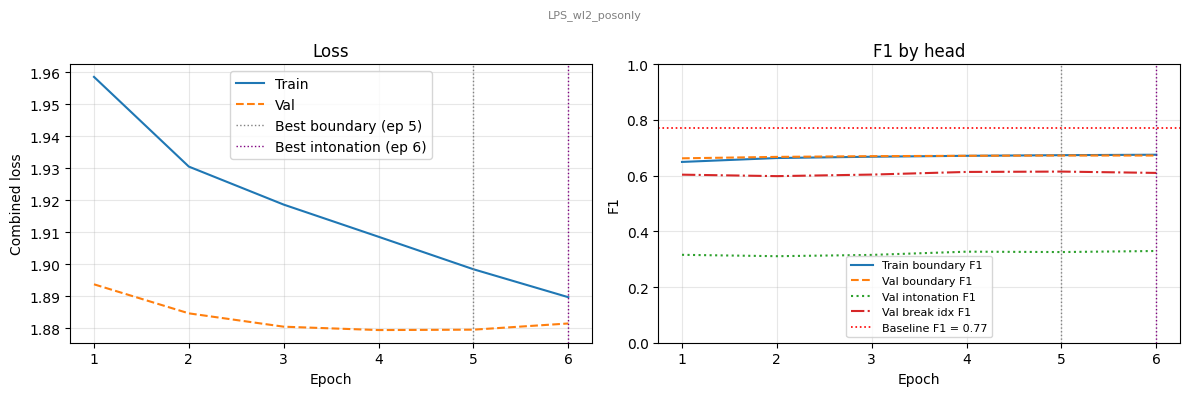

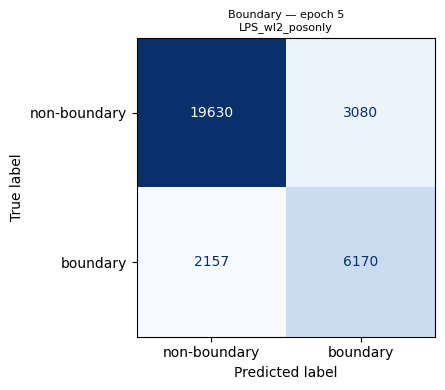

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Saved → /content/drive/MyDrive/Capstone/project/models/full/LPS_wl2_posonly
✓ Registered as model #48
✓ GPU memory cleared.  Allocated: 0.02 GB

  STARTING RUN 2 of 5

██████████████████████████████████████████████████████████████████████
  RUN: LPS_stl_posonly  (full)
  Datasets:    ['sbc', 'libri', 'ps']
  POS mode:    POS-only
  Strip punct: True
  Imbalance:   none  (weight=5.0)
  LR / Epochs: 2e-05 / 6
  Dual ckpt:   True
  Epoch ckpts: [2, 3, 4, 5, 6]  (diagnostic mode)
  Dir:         /content/drive/MyDrive/Capstone/project/models/full/LPS_stl_posonly
██████████████████████████████████████████████████████████████████████
  Training pool: 279,713 samples  (sbc=3,757 + libri=145,111 + ps=130,845)
  Word counts: {'sbc': 431990, 'libri': 2564256, 'ps': 4919077}  (total: 7,915,323)
  Test set: SBC001–005 fixed holdout (383 samples)
  train=248,633  val=31,080  test=383
  Val word counts by corpus: {'sbc': 48144, 'libri': 284955, 'ps': 546571}  (target ≈11% of each corpus's words)



POS tagging sbcsae:   0%|          | 0/42 [00:00<?, ?it/s]

  ✓ 0 new POS files written, 42 already existed (42 total in sbcsae).
  ✓ POS tags loaded for 3,757 / 3,757 samples from sbcsae.
  Generating POS files for libri (clean-100) ...


POS tagging clean-100:   0%|          | 0/34 [00:00<?, ?it/s]

...

  Epoch 5:  val F1=0.6478  →  test F1=0.6764


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 6:  val F1=0.6499  →  test F1=0.6760

Evaluating intonation checkpoint (epoch 5) on test set ...
  INTONATION CKPT TEST SET  (epoch 5)
  Boundary   F1=0.6764  P=0.7356  R=0.6260
  Intonation F1=0.4553  (macro, 3-class)
  Break idx  F1=nan  (macro, 2-class)
  BU break idx F1=0.5564  (intonation ckpt, epoch 5)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Intonation checkpoint saved → /content/drive/MyDrive/Capstone/project/models/full/LPS_stl_posonly/checkpoint_intonation
  BU EVAL SET  (boundary ckpt — break index gold ToBI)
  Break idx  F1=0.5908  (macro, 2-class)


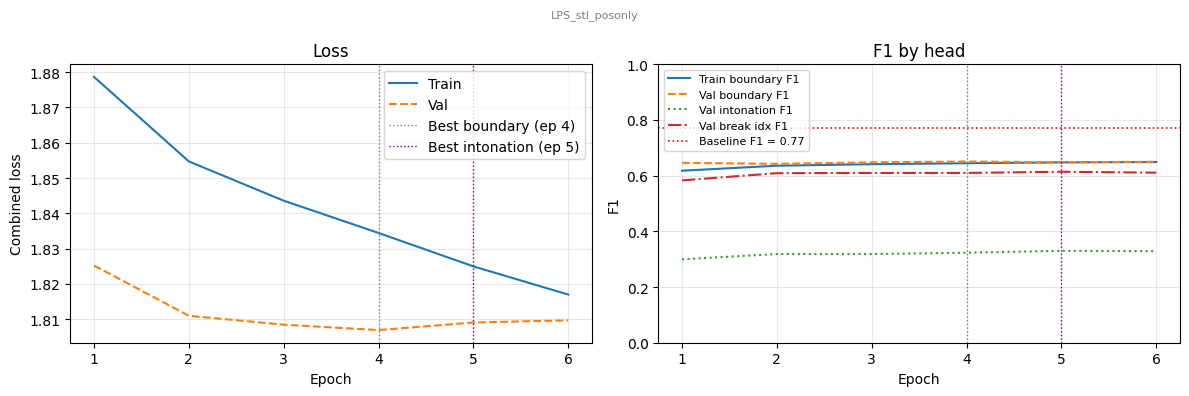

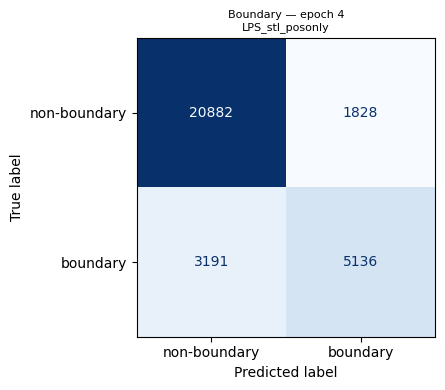

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Saved → /content/drive/MyDrive/Capstone/project/models/full/LPS_stl_posonly
✓ Registered as model #49
✓ GPU memory cleared.  Allocated: 0.02 GB

  STARTING RUN 3 of 5

██████████████████████████████████████████████████████████████████████
  RUN: LP_wl7  (partial)
  Datasets:    ['libri', 'ps']
  POS mode:    text-only
  Strip punct: True
  Imbalance:   weighted_loss  (weight=7.0)
  LR / Epochs: 2e-05 / 6
  Dual ckpt:   True
  Epoch ckpts: [2, 3, 4, 5, 6]  (diagnostic mode)
  Dir:         /content/drive/MyDrive/Capstone/project/models/partial/LP_wl7
██████████████████████████████████████████████████████████████████████
  Training pool: 275,956 samples  (libri=145,111 + ps=130,845)
  Word counts: {'libri': 2564256, 'ps': 4919077}  (total: 7,483,333)
  Test set: SBC001–005 fixed holdout (383 samples)
  train=245,300  val=30,656  test=383
  Val word counts by corpus: {'libri': 284955, 'ps': 546571}  (target ≈11% of each corpus's words)
✓ Datasets built.  pos_ids in batch: False  (expect

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] ProsodyBoundaryModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
boundary_head.weight    | MISSING    | 
intonation_head.bias    | MISSING    | 
boundary_head.bias      | MISSING    | 
break_idx_head.bias     | MISSING    | 
break_idx_head.weight   | MISSING    | 
intonation_head.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded  (66,368,263 trainable params)
  use_pos_embedding=False  pos_emb_dim=64  num_pos_tags=19
ℹ  Weighted loss  [non-boundary=1.0, boundary=7.0]

Training: 6 epochs | 15332 steps/epoch | 91992 total steps


...

  Epoch 5:  val F1=0.7243  →  test F1=0.7906


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 6:  val F1=0.7247  →  test F1=0.7928

Evaluating intonation checkpoint (epoch 6) on test set ...
  INTONATION CKPT TEST SET  (epoch 6)
  Boundary   F1=0.7928  P=0.7486  R=0.8426
  Intonation F1=0.2482  (macro, 3-class)
  Break idx  F1=nan  (macro, 2-class)
  BU break idx F1=0.5981  (intonation ckpt, epoch 6)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Intonation checkpoint saved → /content/drive/MyDrive/Capstone/project/models/partial/LP_wl7/checkpoint_intonation
  BU EVAL SET  (boundary ckpt — break index gold ToBI)
  Break idx  F1=0.6441  (macro, 2-class)


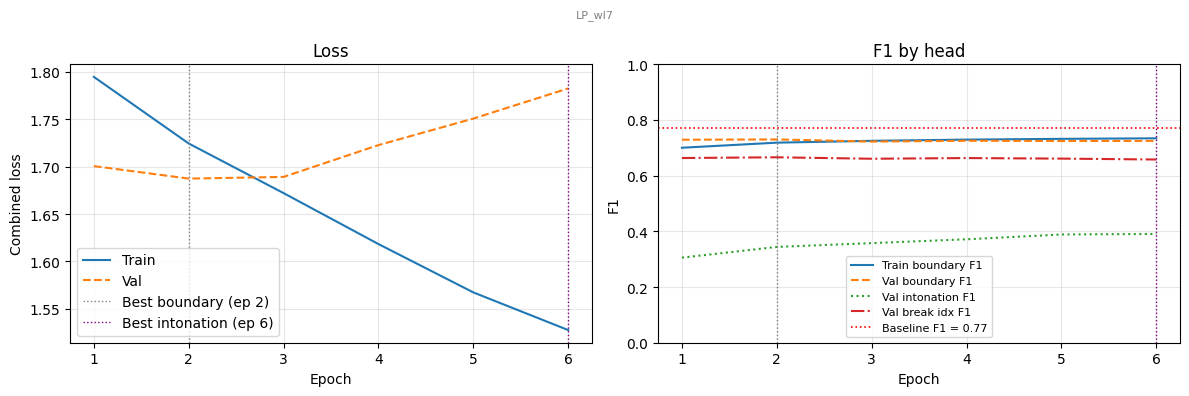

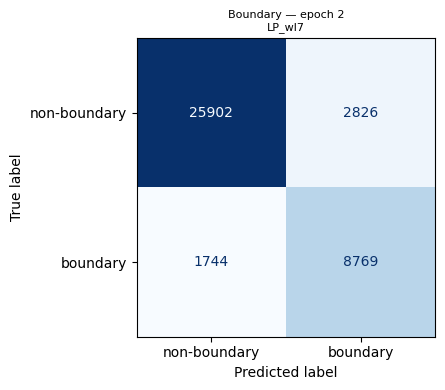

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Saved → /content/drive/MyDrive/Capstone/project/models/partial/LP_wl7
✓ Registered as model #50
✓ GPU memory cleared.  Allocated: 0.02 GB

  STARTING RUN 4 of 5

██████████████████████████████████████████████████████████████████████
  RUN: P_wl7  (partial)
  Datasets:    ['ps']
  POS mode:    text-only
  Strip punct: True
  Imbalance:   weighted_loss  (weight=7.0)
  LR / Epochs: 2e-05 / 6
  Dual ckpt:   True
  Epoch ckpts: [2, 3, 4, 5, 6]  (diagnostic mode)
  Dir:         /content/drive/MyDrive/Capstone/project/models/partial/P_wl7
██████████████████████████████████████████████████████████████████████
  Training pool: 130,845 samples  (ps=130,845)
  Word counts: {'ps': 4919077}  (total: 4,919,077)
  Test set: SBC001–005 fixed holdout (383 samples)
  train=116,334  val=14,511  test=383
  Val word counts by corpus: {'ps': 546571}  (target ≈11% of each corpus's words)
✓ Datasets built.  pos_ids in batch: False  (expected: False)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] ProsodyBoundaryModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
boundary_head.weight    | MISSING    | 
intonation_head.bias    | MISSING    | 
boundary_head.bias      | MISSING    | 
break_idx_head.bias     | MISSING    | 
break_idx_head.weight   | MISSING    | 
intonation_head.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded  (66,368,263 trainable params)
  use_pos_embedding=False  pos_emb_dim=64  num_pos_tags=19
ℹ  Weighted loss  [non-boundary=1.0, boundary=7.0]

Training: 6 epochs | 7271 steps/epoch | 43626 total steps


...

  Epoch 5:  val F1=0.6742  →  test F1=0.7918


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 6:  val F1=0.6740  →  test F1=0.7922

Evaluating intonation checkpoint (epoch 6) on test set ...
  INTONATION CKPT TEST SET  (epoch 6)
  Boundary   F1=0.7922  P=0.7487  R=0.8411
  Intonation F1=0.2348  (macro, 3-class)
  Break idx  F1=nan  (macro, 2-class)
  BU break idx F1=0.5696  (intonation ckpt, epoch 6)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Intonation checkpoint saved → /content/drive/MyDrive/Capstone/project/models/partial/P_wl7/checkpoint_intonation
  BU EVAL SET  (boundary ckpt — break index gold ToBI)
  Break idx  F1=0.5602  (macro, 2-class)


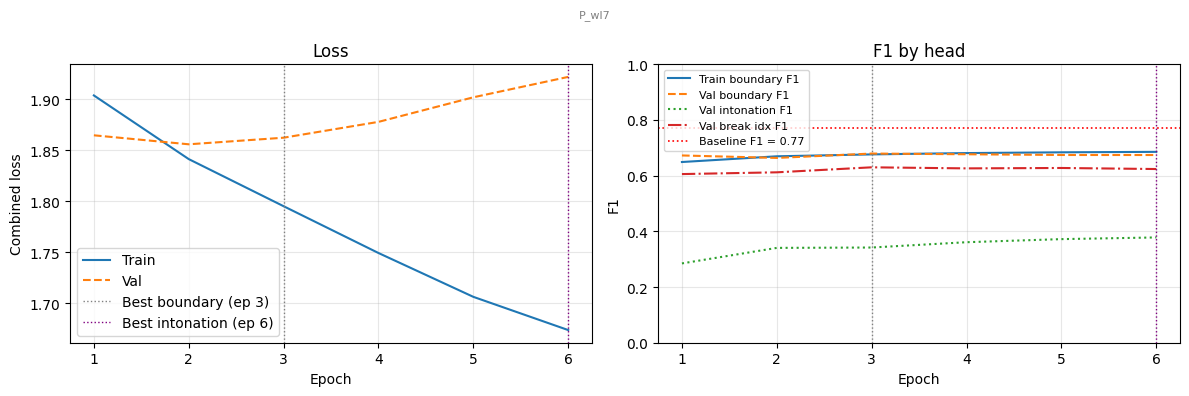

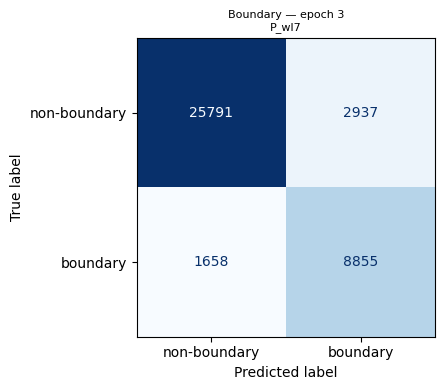

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Saved → /content/drive/MyDrive/Capstone/project/models/partial/P_wl7
✓ Registered as model #51
✓ GPU memory cleared.  Allocated: 0.02 GB

  STARTING RUN 5 of 5

██████████████████████████████████████████████████████████████████████
  RUN: L_wl7_2  (partial)
  (collision with 'L_wl7' — disambiguated)
  Datasets:    ['libri']
  POS mode:    text-only
  Strip punct: True
  Imbalance:   weighted_loss  (weight=7.0)
  LR / Epochs: 2e-05 / 6
  Dual ckpt:   True
  Epoch ckpts: [2, 3, 4, 5, 6]  (diagnostic mode)
  Dir:         /content/drive/MyDrive/Capstone/project/models/partial/L_wl7_2
██████████████████████████████████████████████████████████████████████
  Training pool: 145,111 samples  (libri=145,111)
  Word counts: {'libri': 2564256}  (total: 2,564,256)
  Test set: SBC001–005 fixed holdout (383 samples)
  train=128,966  val=16,145  test=383
  Val word counts by corpus: {'libri': 284955}  (target ≈11% of each corpus's words)
✓ Datasets built.  pos_ids in batch: False  (expected: False)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] ProsodyBoundaryModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
boundary_head.weight    | MISSING    | 
intonation_head.bias    | MISSING    | 
boundary_head.bias      | MISSING    | 
break_idx_head.bias     | MISSING    | 
break_idx_head.weight   | MISSING    | 
intonation_head.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded  (66,368,263 trainable params)
  use_pos_embedding=False  pos_emb_dim=64  num_pos_tags=19
ℹ  Weighted loss  [non-boundary=1.0, boundary=7.0]

Training: 6 epochs | 8061 steps/epoch | 48366 total steps


...

  Epoch 5:  val F1=0.8525  →  test F1=0.7068


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

  Epoch 6:  val F1=0.8484  →  test F1=0.7044

Evaluating intonation checkpoint (epoch 6) on test set ...
  INTONATION CKPT TEST SET  (epoch 6)
  Boundary   F1=0.7044  P=0.6957  R=0.7133
  Intonation F1=0.2213  (macro, 3-class)
  Break idx  F1=nan  (macro, 2-class)
  BU break idx F1=0.5949  (intonation ckpt, epoch 6)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Intonation checkpoint saved → /content/drive/MyDrive/Capstone/project/models/partial/L_wl7_2/checkpoint_intonation
  BU EVAL SET  (boundary ckpt — break index gold ToBI)
  Break idx  F1=0.5964  (macro, 2-class)


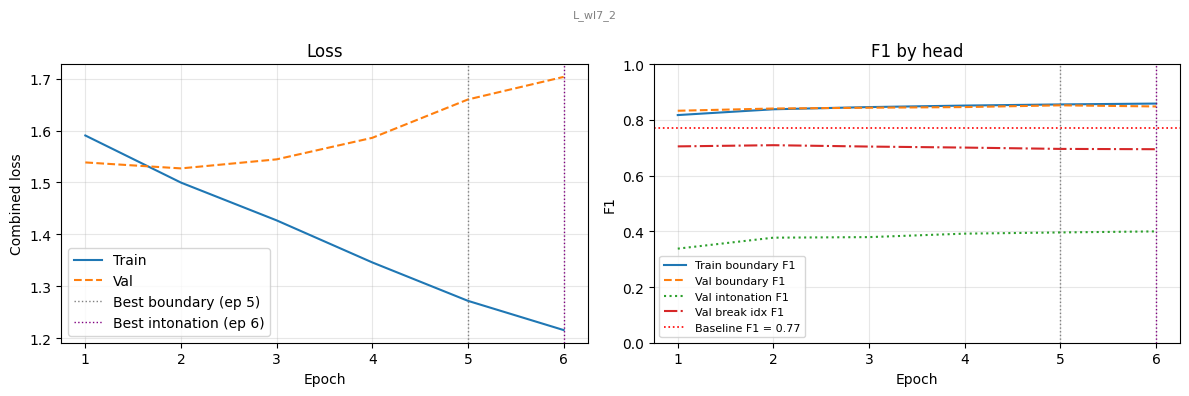

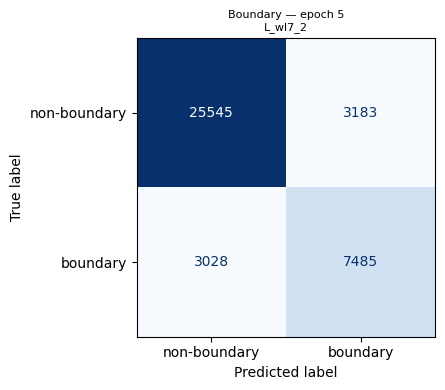

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Saved → /content/drive/MyDrive/Capstone/project/models/partial/L_wl7_2
✓ Registered as model #52
✓ GPU memory cleared.  Allocated: 0.02 GB


██████████████████████████████████████████████████████████████████████
  SUMMARY
██████████████████████████████████████████████████████████████████████
  Model #48   LPS_wl2_posonly                 boundary=0.7021  intonation=0.4670  break=0.5542
  Model #49   LPS_stl_posonly                 boundary=0.6718  intonation=0.4626  break=0.5908
  Model #50   LP_wl7                          boundary=0.7933  intonation=0.2074  break=0.6441
  Model #51   P_wl7                           boundary=0.7940  intonation=0.2210  break=0.5602
  Model #52   L_wl7_2                         boundary=0.7068  intonation=0.2230  break=0.5964
██████████████████████████████████████████████████████████████████████


'\nfor r in results_summary:\n    b  = r["test_metrics"]["boundary"]["f1"]\n    iv = r["test_metrics"]["intonation"]["f1"]\n    hp_path = os.path.join(r["run_dir"], "hparams.json")\n    with open(hp_path) as f:\n        hp = json.load(f)\n    bu_f1 = hp.get("results", {}).get("bu_eval", {}) or {}\n    x = bu_f1.get("f1")\n    x_str = f"{x:.4f}" if x is not None else "n/a"\n\n    print(f"  Model #{r[\'model_number\']:<4} {r[\'run_id\']:<30}  "\n          f"boundary={b:.4f}  intonation={iv:.4f}  break={x_str}")\n'

In [ ]:
results_summary = []
for i, run_def in enumerate(RUNS):
    print(f"\n{'='*70}\n  STARTING RUN {i+1} of {len(RUNS)}\n{'='*70}")
    result = run_experiment(
        overrides=run_def["overrides"],
        datasets=run_def["datasets"],
    )
    results_summary.append(result)

print("\n\n" + "█"*70)
print("  SUMMARY")
print("█"*70)

for r in results_summary:
    import os, json
    hp = json.load(open(os.path.join(r["run_dir"], "hparams.json")))
    b  = r["test_metrics"]["boundary"]["f1"]
    iv = r["test_metrics"]["intonation"]["f1"]
    bu = (hp.get("results", {}).get("bu_eval") or {}).get("f1")
    x_str = f"{bu:.4f}" if bu is not None else "n/a"
    print(f"  Model #{r['model_number']:<4} {r['run_id']:<30}  "
          f"boundary={b:.4f}  intonation={iv:.4f}  break={x_str}")
print("█"*70)

'''
for r in results_summary:
    b  = r["test_metrics"]["boundary"]["f1"]
    iv = r["test_metrics"]["intonation"]["f1"]
    hp_path = os.path.join(r["run_dir"], "hparams.json")
    with open(hp_path) as f:
        hp = json.load(f)
    bu_f1 = hp.get("results", {}).get("bu_eval", {}) or {}
    x = bu_f1.get("f1")
    x_str = f"{x:.4f}" if x is not None else "n/a"

    print(f"  Model #{r['model_number']:<4} {r['run_id']:<30}  "
          f"boundary={b:.4f}  intonation={iv:.4f}  break={x_str}")
'''

In [ ]:
'''
# Run this in Colab, in a cell with Drive already mounted.
# Removes "/" (speaker-change token) entries from every sample in every
# batch_*.json file under SBC_LABELS_ROOT. Edits tokens, b.consensus, and
# i.labels in lockstep (x is always None for SBC, nothing to touch there).

import json, os, shutil

SBC_LABELS_ROOT = f"{DRIVE_ROOT}/labels/sbcsae"   # adjust if DRIVE_ROOT not in scope
SPK_TOKEN = "/"
BACKUP_DIR = os.path.join(SBC_LABELS_ROOT, "_backup_pre_spk_removal")

batch_files = sorted(
    f for f in os.listdir(SBC_LABELS_ROOT)
    if f.startswith("batch_") and f.endswith(".json")
)
print(f"Found {len(batch_files)} batch files in {SBC_LABELS_ROOT}\n")

# ── Backup (one-time) ──────────────────────────────────────────────────────
if os.path.isdir(BACKUP_DIR):
    print(f"⚠  Backup already exists at {BACKUP_DIR} — skipping backup step.")
    print(f"   (Delete that folder first if you want a fresh backup.)\n")
else:
    os.makedirs(BACKUP_DIR, exist_ok=True)
    for fname in batch_files:
        shutil.copy2(
            os.path.join(SBC_LABELS_ROOT, fname),
            os.path.join(BACKUP_DIR, fname),
        )
    print(f"✓ Backed up {len(batch_files)} files → {BACKUP_DIR}\n")

total_samples_touched = 0
total_tokens_removed   = 0

for fname in batch_files:
    path = os.path.join(SBC_LABELS_ROOT, fname)
    with open(path) as f:
        batch = json.load(f)

    file_touched = False
    file_removed = 0

    for sid, data in batch.items():
        tokens    = data["b"]["tokens"]
        consensus = data["b"]["consensus"]
        i_labels  = data["i"]["labels"]
        # i.tokens mirrors b.tokens in this schema — keep them in sync
        i_tokens  = data["i"]["tokens"]

        if SPK_TOKEN not in tokens:
            continue

        # Find indices to remove
        keep_idx = [idx for idx, t in enumerate(tokens) if t != SPK_TOKEN]
        n_removed = len(tokens) - len(keep_idx)

        # Sanity check: all four arrays must be the same length before editing
        if not (len(tokens) == len(consensus) == len(i_labels) == len(i_tokens)):
            print(f"  ⚠ {sid}: array length mismatch BEFORE edit — skipping sample.")
            continue

        data["b"]["tokens"]    = [tokens[idx]    for idx in keep_idx]
        data["b"]["consensus"] = [consensus[idx] for idx in keep_idx]
        data["i"]["labels"]    = [i_labels[idx]  for idx in keep_idx]
        data["i"]["tokens"]    = [i_tokens[idx]  for idx in keep_idx]

        # Sanity check: lengths still consistent after edit
        new_len = len(data["b"]["tokens"])
        if not (new_len == len(data["b"]["consensus"]) == len(data["i"]["labels"]) == len(data["i"]["tokens"])):
            print(f"  ✗ {sid}: array length mismatch AFTER edit — this sample is now broken!")
            continue

        file_touched = True
        file_removed += n_removed
        total_samples_touched += 1

    if file_touched:
        with open(path, "w") as f:
            json.dump(batch, f, indent=2)
        print(f"  ✓ {fname}: removed {file_removed} speaker-change tokens")
        total_tokens_removed += file_removed
    else:
        print(f"  –  {fname}: no speaker-change tokens found (already clean)")

print(f"\n{'='*60}")
print(f"  DONE")
print(f"{'='*60}")
print(f"  Samples touched:        {total_samples_touched:,}")
print(f"  Total tokens removed:   {total_tokens_removed:,}")

SyntaxError: incomplete input (2837620056.py, line 1)

In [ ]:
'''
# Run in Colab (or anywhere with access to the label files).
# Reformats every batch_*.json under the given roots so that any JSON array
# containing only scalars (strings/numbers/null/bool — no nested objects or
# arrays) is collapsed onto a single line, while objects/dicts keep normal
# multi-line indentation. This matches the style already used by the BU
# pipeline's _flush_buffer() collapsing regex, just applied uniformly and
# safely via json.dumps + a custom encoder rather than regex post-processing.
#
# Safe to re-run: output is idempotent (re-collapsing an already-collapsed
# file produces the same result).

import json, os

def _collapse_flat_arrays(obj):
    """
    Recursively walk obj. Any list containing only scalars (no dict/list
    elements) is wrapped in a marker so the custom encoder can render it
    inline. Lists containing dicts/lists are left as normal lists (each
    element still gets its own multi-line treatment).
    """
    if isinstance(obj, dict):
        return {k: _collapse_flat_arrays(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        is_flat = all(not isinstance(x, (dict, list)) for x in obj)
        if is_flat:
            return _FlatList(obj)
        else:
            return [_collapse_flat_arrays(x) for x in obj]
    else:
        return obj


class _FlatList(list):
    """Marker subclass — tells the encoder to render this list inline."""
    pass


class _CollapsingEncoder(json.JSONEncoder):
    def default(self, obj):
        return super().default(obj)


def _dumps_with_collapsed_arrays(obj, indent=2):
    """
    Custom serializer: dict/list-of-dict structure gets normal pretty
    printing; any _FlatList gets rendered as a single-line JSON array
    using the standard (compact) encoder, then spliced back in.
    """
    PLACEHOLDER = "__FLATLIST_PLACEHOLDER_{}__"

    flat_lists = []

    def _replace_flatlists(o):
        if isinstance(o, _FlatList):
            idx = len(flat_lists)
            flat_lists.append(json.dumps(list(o), separators=(", ", ": ")))
            return PLACEHOLDER.format(idx)
        elif isinstance(o, dict):
            return {k: _replace_flatlists(v) for k, v in o.items()}
        elif isinstance(o, list):
            return [_replace_flatlists(x) for x in o]
        else:
            return o

    prepared = _replace_flatlists(obj)
    raw = json.dumps(prepared, indent=indent)

    # Splice the flat-list strings back in, removing the quotes the
    # placeholder string picked up from being serialized as a JSON string.
    for idx, flat_str in enumerate(flat_lists):
        quoted_placeholder = '"' + PLACEHOLDER.format(idx) + '"'
        if quoted_placeholder not in raw:
            raise RuntimeError(
                f"Internal error: placeholder {idx} not found in serialized "
                f"output. This shouldn't happen — please report."
            )
        raw = raw.replace(quoted_placeholder, flat_str)

    return raw


def collapse_batch_files(root, label=""):
    """
    Rewrite every batch_*.json under root with flat arrays collapsed onto
    single lines. Returns (n_files, n_bytes_before, n_bytes_after).
    """
    batch_files = sorted(
        f for f in os.listdir(root)
        if f.startswith("batch_") and f.endswith(".json")
    )
    if not batch_files:
        print(f"  ⚠ No batch files in {root}")
        return 0, 0, 0

    tag = f" [{label}]" if label else ""
    total_before, total_after = 0, 0

    for fname in batch_files:
        path = os.path.join(root, fname)
        with open(path) as f:
            raw_before = f.read()

        # Safety check: bail if the placeholder pattern already appears in
        # the raw file content (would only happen if real data contained
        # this exact string, astronomically unlikely but checked anyway).
        if "__FLATLIST_PLACEHOLDER_" in raw_before:
            print(f"  ✗ {fname}: contains reserved placeholder string — SKIPPED.")
            continue

        data = json.loads(raw_before)

        prepared = _collapse_flat_arrays(data)
        raw_after = _dumps_with_collapsed_arrays(prepared, indent=2)

        # Verify the collapsed version round-trips to the same data —
        # never write a file that doesn't parse back identically.
        if json.loads(raw_after) != data:
            print(f"  ✗ {fname}: round-trip mismatch — SKIPPED, file left unchanged.")
            continue

        with open(path, "w") as f:
            f.write(raw_after)

        total_before += len(raw_before)
        total_after  += len(raw_after)

    print(f"  ✓{tag} {len(batch_files)} files collapsed  "
          f"({total_before:,} → {total_after:,} bytes)")
    return len(batch_files), total_before, total_after


# ── Run across all corpora ──────────────────────────────────────────────────
roots_to_process = [
    (BATCHED_ROOT_LIBRI_100, "libri-100"),
    (BATCHED_ROOT_LIBRI_360, "libri-360"),
    (BATCHED_ROOT_SBC,       "sbcsae"),
    (BATCHED_ROOT_BU,        "bu"),
    (BATCHED_ROOT_PS,        "ps"),
]

print("Collapsing flat arrays in batch JSON files...\n")
grand_total_files = 0
for root, label in roots_to_process:
    if os.path.isdir(root):
        n, _, _ = collapse_batch_files(root, label)
        grand_total_files += n
    else:
        print(f"  –  {root} doesn't exist, skipping")

print(f"\n✓ Done. {grand_total_files} total batch files reformatted.")